In [4]:
import sys,copy,os,inspect
if hasattr(sys.modules[__name__], '__file__'):
    _file_name = __file__
else:
    _file_name = inspect.getfile(inspect.currentframe())
CURRENT_FILE_PATH = os.path.dirname(_file_name)
sys.path.append(os.getcwd()+"/../neuronVis")
import IONData 
iondata = IONData.IONData()

In [5]:
import pandas as pd

def loadClusterCSV(filename,cluster=None):
    neurons = pd.read_csv(filename)
    neuronsArray= neurons.to_numpy()
    neuronScene=[]
    for neuron in neuronsArray:
        # print(str(neuron[2])[0])
        neurondict={}
        neurondict['cluster'] = neuron[1]
        neurondict['sampleid'] = str(neuron[2])[0:6]
        neurondict['name']=str(neuron[2])[6:]+'.swc'
        property = iondata.getNeuronPropertyByID(neurondict['sampleid'], neurondict['name'])
        neurondict['soma']=property['somaregion']
        if cluster ==neuron[1] or cluster ==None:
            neuronScene.append(neurondict)
    return neuronScene

def rgbToHex(r,g,b):
    rgb = [r,g,b]
    x = ''
    for i in rgb:
      x += format(i,'02x').upper()
    if x[0] == x[1] and x[2] == x[3] and x[4] == x[5]:
      x = x[0] + x[2] + x[4]
    return '#'+x
print(rgbToHex(1,0,0))

#010000


In [ ]:
import Scene
neuronScene = loadClusterCSV("../resource/cluster_eachNeuron/cluster_eachNeuron_TH.csv")
Scene.createScene(neuronScene,"../resource/TH.nv")
neuronScene = loadClusterCSV("../resource/cluster_eachNeuron/cluster_eachNeuron_spcd.csv")
Scene.createScene(neuronScene,"../resource/cluster_eachNeuron/cluster_eachNeuron_spcd.nv")
# import Visual as nv

# neuronvis = nv.neuronVis(renderModel=1)
# neuronvis.render.setBackgroundColor((0.0,0.20,0.5,1.0))
# for neuron in neuronScene[36:37]:
# 	neuronT = iondata.getNeuronTreeByID(neuron['sampleid'], neuron['name'])
# 	neuronvis.addNeuronTree(neuronT,'200313-083.swc',somaColor=[1,0,0],axonColor=[0,1,0],dendriteColor=[0,0,1])

# neuronvis.render.run()



In [6]:
import Scene
neuronScene = Scene.scene2List("../resource/scene/22024thneurons.nv")
print(neuronScene)

[{'color': {'b': '130', 'g': '141', 'r': '178'}, 'name': '001.swc', 'sampleid': '220240'}, {'color': {'b': '94', 'g': '156', 'r': '214'}, 'name': '002.swc', 'sampleid': '220240'}, {'color': {'b': '111', 'g': '54', 'r': '204'}, 'name': '003.swc', 'sampleid': '220240'}, {'color': {'b': '130', 'g': '91', 'r': '41'}, 'name': '004.swc', 'sampleid': '220240'}, {'color': {'b': '124', 'g': '58', 'r': '74'}, 'name': '006.swc', 'sampleid': '220240'}, {'color': {'b': '4', 'g': '152', 'r': '241'}, 'name': '025.swc', 'sampleid': '220240'}, {'color': {'b': '7', 'g': '86', 'r': '225'}, 'name': '029.swc', 'sampleid': '220240'}, {'color': {'b': '17', 'g': '220', 'r': '140'}, 'name': '030.swc', 'sampleid': '220240'}, {'color': {'b': '139', 'g': '73', 'r': '190'}, 'name': '031.swc', 'sampleid': '220240'}, {'color': {'b': '59', 'g': '160', 'r': '71'}, 'name': '032.swc', 'sampleid': '220240'}, {'color': {'b': '19', 'g': '243', 'r': '209'}, 'name': '033.swc', 'sampleid': '220240'}, {'color': {'b': '19', 'g'

In [ ]:
import pickle

f = open('../resource/cluster_eachNeuron/TH20221208.pckl', 'rb')
obj = pickle.load(f)
f.close()

neuronScene=[]
for neuron in obj:
        # print(str(neuron[2])[0])
        neurondict={}
        neurondict['sampleid'] = str(neuron)[0:6]
        neurondict['name']=str(neuron)[6:]

        neuronScene.append(neurondict)

In [ ]:
import Visual as nv
import random
neuronvis = nv.neuronVis(renderModel=1)
neuronvis.render.setBackgroundColor((1.0,1.0,1.0,1.0))
for neuron in neuronScene[:]:
	neuronT = iondata.getNeuronTreeByID(neuron['sampleid'], neuron['name'])
	color=[random.random(),random.random(),random.random()]

	neuronvis.addNeuronTree(neuronT,'200313-083.swc',color=color)
	# break

neuronvis.render.run()

exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210098/001.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210098/002.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210098/003.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210098/004.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210098/011.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210098/012.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210098/013.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210098/014.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210098/015.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210098/016.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210098/017.swc
exist  d:\project\python\neuron-

In [7]:
import BrainRegion as BR 
import numpy as np
br = BR.BrainRegion()
br.praseJson()


# neurons = Scene.scene2List("../resource/TH.nv")
neurons = neuronScene
#target_regions = ['SSp','SSs','VISC','GU','VISp','VISam','VISpm','VISa','AUDp','AUDv','AUDd','TEa','MOp','MOs','ORBl','ORBvl','ORBm','PL','AIv','AIp','AId','ACAd','ACAv','RSPagl','RSPd']
target_regions = ['FRP','MOp','MOs','SSp','SSs','GU','VISC','AUDp','AUDv','AUDd','VISp','VISam','VISpm','VISa','ACAd','ACAv','PL','ILA','ORBl','ORBvl','ORBm','AIv','AIp','AId',
'RSPagl','RSPd','PTLp','TEa','PERI','ECT',
'STRd','STRv','LSX','sAMY','MB','HB','TH','HY','OLF','HPF','CTXsp','PAL','CB']

# source_regions_sort_index = ['VPM','VPL','VPMpc','VPLpc','LGd','MG','VAL','AM','SMT','MD','LP','PO','LD','VM','RE','CM','TH','ar','CL','Eth','PIL','PoT','SPFp','ZI','PF']
source_regions_sort_index=['VPMpc', 'MD', 'CM', 'CL', 'PF']
source_regions_color=[[179,238,58],[0,100,0],[255,0,0],[0,0,255],[139,101,8],[205,104,57],
[255,0,255],[255,250,205],[255,20,147],[255,225,255],[207,207,207],[144,238,144],
[180,205,205],[110,123,139],[205,201,165],[238,106,167],[255,228,196],[216,191,216],
[238,154,0],[205,133,0],[205,91,69],[255,20,147],[255,52,179],[0,191,255]
]
regionNeurons={}
for regions in source_regions_sort_index:
    regionNeurons[regions]=[]
for neuron in neurons:
    property = iondata.getNeuronPropertyByID(neuron['sampleid'], neuron['name'])
    if property['somaregion'] not in source_regions_sort_index:
        continue
    else:
        regionNeurons[property['somaregion']].append(neuron)
# print(regionNeurons)
propmat=[]
regionpropmat=[]
for region,neuronsInRegion in regionNeurons.items():
    regionprop=[]
    propmat2=[]
    for neuron in neuronsInRegion:
        property = iondata.getNeuronPropertyByID(neuron['sampleid'], neuron['name'])
        brproperty=BR.RegionProperty(copy.deepcopy(br))
        brpropertyLeft=BR.RegionProperty(copy.deepcopy(br))
        brpropertyRight=BR.RegionProperty(copy.deepcopy(br))
        brproperty.setProperty(property['projectregion'])
        brpropertyLeft.setProperty(property['projectleftregion'])
        brpropertyRight.setProperty(property['projectrightregion'])
        prop=[]
        for targetRegion in target_regions:
            regionsum = brproperty.getSumProperty(targetRegion)
            regionleft = brpropertyLeft.getSumProperty(targetRegion)
            regionright = brpropertyRight.getSumProperty(targetRegion)
            ipsi=0
            contra=0
            if property['somapoint'][2]<5700:
                ipsi=regionleft
                contra=regionright
            else:
                ipsi=regionright
                contra=regionleft
            prop.append(ipsi)
        propmat.append(prop)
        propmat2.append(prop)
    if len(propmat2)>0:
        temp = np.array(propmat2)
        regionprop = temp.sum(0)
        regionpropmat.append(list(regionprop))


write  d:\project\python\neuron-vis\figures/../neuronVis/../resource/json/220240/001.swc.json
write  d:\project\python\neuron-vis\figures/../neuronVis/../resource/json/220240/002.swc.json
write  d:\project\python\neuron-vis\figures/../neuronVis/../resource/json/220240/003.swc.json
write  d:\project\python\neuron-vis\figures/../neuronVis/../resource/json/220240/004.swc.json
write  d:\project\python\neuron-vis\figures/../neuronVis/../resource/json/220240/006.swc.json
write  d:\project\python\neuron-vis\figures/../neuronVis/../resource/json/220240/025.swc.json
write  d:\project\python\neuron-vis\figures/../neuronVis/../resource/json/220240/029.swc.json
write  d:\project\python\neuron-vis\figures/../neuronVis/../resource/json/220240/030.swc.json
write  d:\project\python\neuron-vis\figures/../neuronVis/../resource/json/220240/031.swc.json
write  d:\project\python\neuron-vis\figures/../neuronVis/../resource/json/220240/032.swc.json
write  d:\project\python\neuron-vis\figures/../neuronVis/../

In [8]:
regionNeurons

{'VPMpc': [{'color': {'b': '232', 'g': '103', 'r': '163'},
   'name': '057.swc',
   'sampleid': '220241'}],
 'MD': [{'color': {'b': '4', 'g': '152', 'r': '241'},
   'name': '025.swc',
   'sampleid': '220240'},
  {'color': {'b': '224', 'g': '53', 'r': '35'},
   'name': '016.swc',
   'sampleid': '220241'},
  {'color': {'b': '120', 'g': '186', 'r': '245'},
   'name': '017.swc',
   'sampleid': '220241'},
  {'color': {'b': '36', 'g': '108', 'r': '14'},
   'name': '030.swc',
   'sampleid': '220241'},
  {'color': {'b': '162', 'g': '134', 'r': '29'},
   'name': '037.swc',
   'sampleid': '220241'},
  {'color': {'b': '43', 'g': '156', 'r': '2'},
   'name': '038.swc',
   'sampleid': '220241'},
  {'color': {'b': '156', 'g': '143', 'r': '156'},
   'name': '039.swc',
   'sampleid': '220241'},
  {'color': {'b': '115', 'g': '116', 'r': '111'},
   'name': '040.swc',
   'sampleid': '220241'},
  {'color': {'b': '5', 'g': '84', 'r': '24'},
   'name': '041.swc',
   'sampleid': '220241'},
  {'color': {'b': 

In [9]:
for region in source_regions_sort_index:
    Scene.createScene(regionNeurons[region],"../resource/THWQM_"+region+".nv")

In [24]:
Scene.createScene(regionNeurons['VPM'],"../resource/TH_VPM.nv")
# regionNeurons['VPL']
list2=[]
for region in source_regions_sort_index:
    for neuron in regionNeurons[region]:
            list2.append("D:/project/python/neuron-vis/resource/swc/"+neuron['sampleid']+"/"+neuron['name'])

f=open("../resource/22024neurons.txt","w")
 
for line in list2:
    f.write(line+'\n')
f.close()

range(0, 5) ['VPMpc', 'MD', 'CM', 'CL', 'PF'] [1, 16, 1, 5, 43]


<BarContainer object of 5 artists>

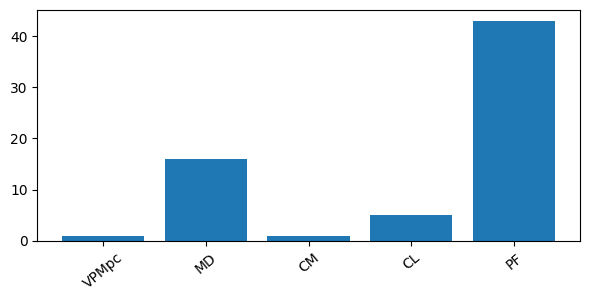

In [10]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.use('module://matplotlib_inline.backend_inline')
%matplotlib inline
# regionNeurons
label=[] 
regionNeuronCount=[]
for key,neurons in regionNeurons.items():
    if len(neurons)>0:
        label.append(key)
        regionNeuronCount.append(len(neurons))
x = range(len(regionNeuronCount))

print(x,label,regionNeuronCount)
fig,ax = plt.subplots(figsize=(7,3))
plt.xticks(x,label,rotation = 40)
plt.bar(x,regionNeuronCount)

([], [])

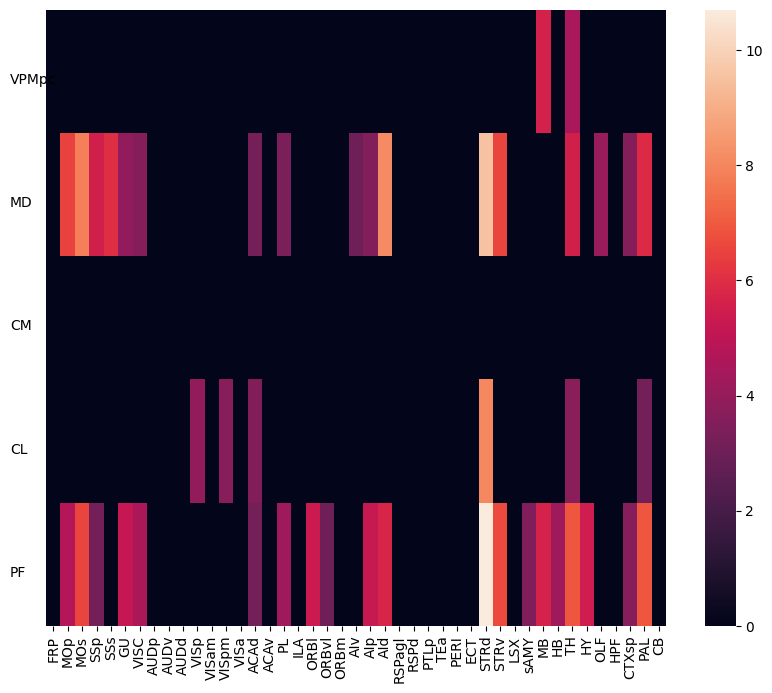

In [11]:
import numpy as np 
import seaborn	as sns


mat = np.array(regionpropmat)
mat = np.log2(mat/1000.0+1)
mat[mat<3]=0
fig,ax = plt.subplots(figsize=(10,8))

sns.heatmap(mat)
plt.xticks([index+0.5 for index in range(len(target_regions))],target_regions,rotation = 90)
sum=0
for i in range(len(regionNeuronCount)):
    index  = i
    if regionNeuronCount[index]>0:
        # y = regionNeuronCount[index]/2+sum+1
        sum+=1
        plt.text(-2.5,sum-0.4,label[index])

plt.yticks([])

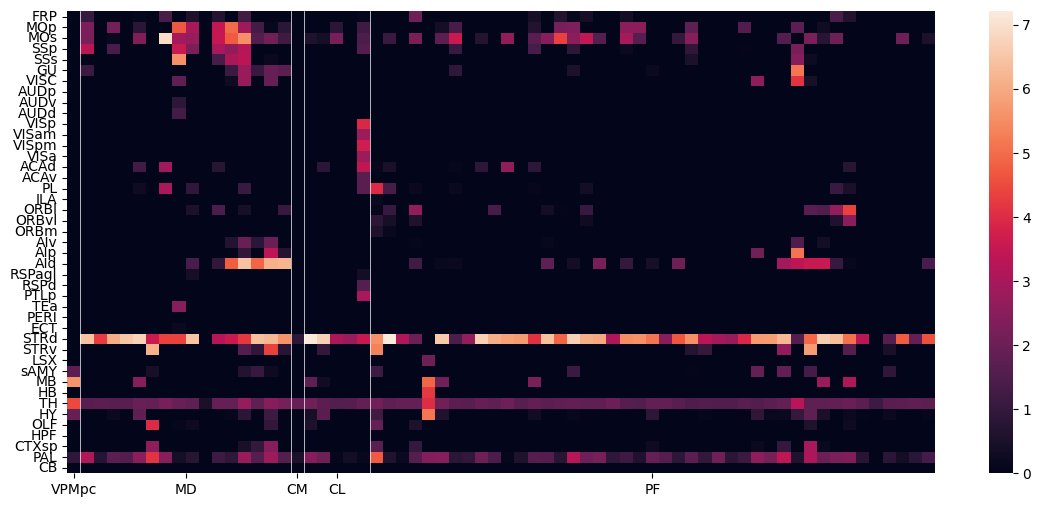

In [12]:
import numpy as np 
import seaborn	as sns


mat = np.array(propmat)
mat = np.log2(mat/1000.0+1)

fig,ax = plt.subplots(figsize=(14,6))

sns.heatmap(mat.T)
plt.yticks([index+0.5 for index in range(len(target_regions))],target_regions,rotation = 0)
sum=0
yindex=[]
ylabels=[]
for i in range(len(regionNeuronCount)):
    index  = i
    if regionNeuronCount[index]>0:
        y = regionNeuronCount[index]/2+sum
        sum+=regionNeuronCount[index]
        yindex.append(y)
        ylabels.append(source_regions_sort_index[index])
plt.xticks(yindex,ylabels)

sum=0
for i in range(len(regionNeuronCount)):
    index  = i
    if regionNeuronCount[index]>0:
        sum+=regionNeuronCount[index]
        plt.axvline(x=sum,ls="-",c="white", linewidth=0.5)
# plt.yticks([])

In [98]:
matdf = pd.DataFrame(mat,columns=target_regions)
matdf

,FRP,MOp,MOs,SSp,SSs,GU,VISC,AUDp,AUDv,AUDd,...,sAMY,MB,HB,TH,HY,OLF,HPF,CTXsp,PAL,CB
0,0.0,0.000000,0.000000,4.808906,4.347913,0.000000,3.544560,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,1.334446,0.000000,0.0,0.0,0.000000,0.448358,0.0
1,0.0,5.823358,1.708487,5.566273,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,2.276096,0.000000,0.0,0.0,0.000000,0.000000,0.0
2,0.0,4.072095,3.098385,5.838963,4.834211,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,2.112009,0.000000,0.0,0.0,0.000000,0.000000,0.0
3,0.0,0.000000,0.000000,3.166104,5.137638,1.652982,4.831339,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,2.289376,0.000000,0.0,0.0,1.003760,0.690006,0.0
4,0.0,0.000000,0.000000,2.188530,4.777809,0.000000,1.470735,0.000000,1.038812,3.408661,...,0.0,0.0,0.0,1.247280,0.000000,0.0,0.0,0.000000,0.182846,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0
209,0.0,0.000000,0.000000,0.000000,3.191246,0.000000,0.284319,1.215027,4.912297,4.910434,...,0.0,0.0,0.0,0.040536,0.849272,0.0,0.0,0.000000,0.162213,0.0
210,0.0,3.712174,0.181995,4.780139,3.219341,0.000000,0.967719,0.000000,2.246798,4.050249,...,0.0,0.0,0.0,0.051748,0.965033,0.0,0.0,0.264167,0.354367,0.0
211,0.0,2.203753,0.000000,4.878152,4.593445,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.393349,0.312433,0.0,0.0,0.000000,0.045127,0.0


In [13]:
matdf.shape[0]

194

([<matplotlib.axis.YTick at 0x2b5e7831070>,
 [Text(0, 0.5, 'FRP'),
  Text(0, 1.5, 'MOp'),
  Text(0, 2.5, 'MOs'),
  Text(0, 3.5, 'SSp'),
  Text(0, 4.5, 'SSs'),
  Text(0, 5.5, 'GU'),
  Text(0, 6.5, 'VISC'),
  Text(0, 7.5, 'AUDp'),
  Text(0, 8.5, 'AUDv'),
  Text(0, 9.5, 'AUDd'),
  Text(0, 10.5, 'VISp'),
  Text(0, 11.5, 'VISam'),
  Text(0, 12.5, 'VISpm'),
  Text(0, 13.5, 'VISa'),
  Text(0, 14.5, 'ACAd'),
  Text(0, 15.5, 'ACAv'),
  Text(0, 16.5, 'PL'),
  Text(0, 17.5, 'ILA'),
  Text(0, 18.5, 'ORBl'),
  Text(0, 19.5, 'ORBvl'),
  Text(0, 20.5, 'ORBm'),
  Text(0, 21.5, 'AIv'),
  Text(0, 22.5, 'AIp'),
  Text(0, 23.5, 'AId'),
  Text(0, 24.5, 'RSPagl'),
  Text(0, 25.5, 'RSPd'),
  Text(0, 26.5, 'PTLp'),
  Text(0, 27.5, 'TEa'),
  Text(0, 28.5, 'PERI'),
  Text(0, 29.5, 'ECT'),
  Text(0, 30.5, 'STRd'),
  Text(0, 31.5, 'STRv'),
  Text(0, 32.5, 'LSX'),
  Text(0, 33.5, 'sAMY'),
  Text(0, 34.5, 'MB'),
  Text(0, 35.5, 'HB'),
  Text(0, 36.5, 'TH'),
  Text(0, 37.5, 'HY'),
  Text(0, 38.5, 'OLF'),
  Text(0, 3

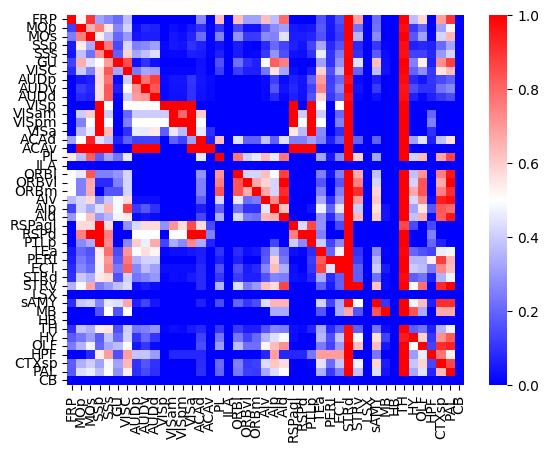

In [10]:
score=np.zeros([len(target_regions),len(target_regions)])
for i in range(len(target_regions)):
    region  =target_regions[i]
    temp = matdf[matdf[region]>0.5]
    for  j in range(len(target_regions)):
        region1  =target_regions[j]

        temp1 =temp[temp[region1]>0.5]
        if temp.shape[0]>0:
            score[i,j]=temp1.shape[0]/temp.shape[0]
sns.heatmap(score,cmap='bwr')
plt.xticks([index+0.5 for index in range(len(target_regions))],target_regions,rotation = 90)
plt.yticks([index+0.5 for index in range(len(target_regions))],target_regions,rotation = 0)

In [105]:

propmat0=[]
columes =  []
for region in source_regions_sort_index:

    for neuron in regionNeurons[region]:
            property = iondata.getNeuronPropertyByID(neuron['sampleid'], neuron['name'])
            brproperty=BR.RegionProperty(copy.deepcopy(br))
            brpropertyLeft=BR.RegionProperty(copy.deepcopy(br))
            brpropertyRight=BR.RegionProperty(copy.deepcopy(br))
            brproperty.setProperty(property['projectregion'])
            brpropertyLeft.setProperty(property['projectleftregion'])
            brpropertyRight.setProperty(property['projectrightregion'])
            prop=[]
            for targetRegion in target_regions:
                regionsum = brproperty.getSumProperty(targetRegion)
                regionleft = brpropertyLeft.getSumProperty(targetRegion)
                regionright = brpropertyRight.getSumProperty(targetRegion)
                ipsi=0
                contra=0
                if property['somapoint'][2]<5700:
                    ipsi=regionleft
                    contra=regionright
                else:
                    ipsi=regionright
                    contra=regionleft
                prop.append(ipsi)
            if np.array(prop).sum()>10:
                columes.append(neuron['sampleid']+neuron['name'])
                propmat0.append(prop)

import numpy as np 
import seaborn	as sns




In [96]:
len(columes)

184

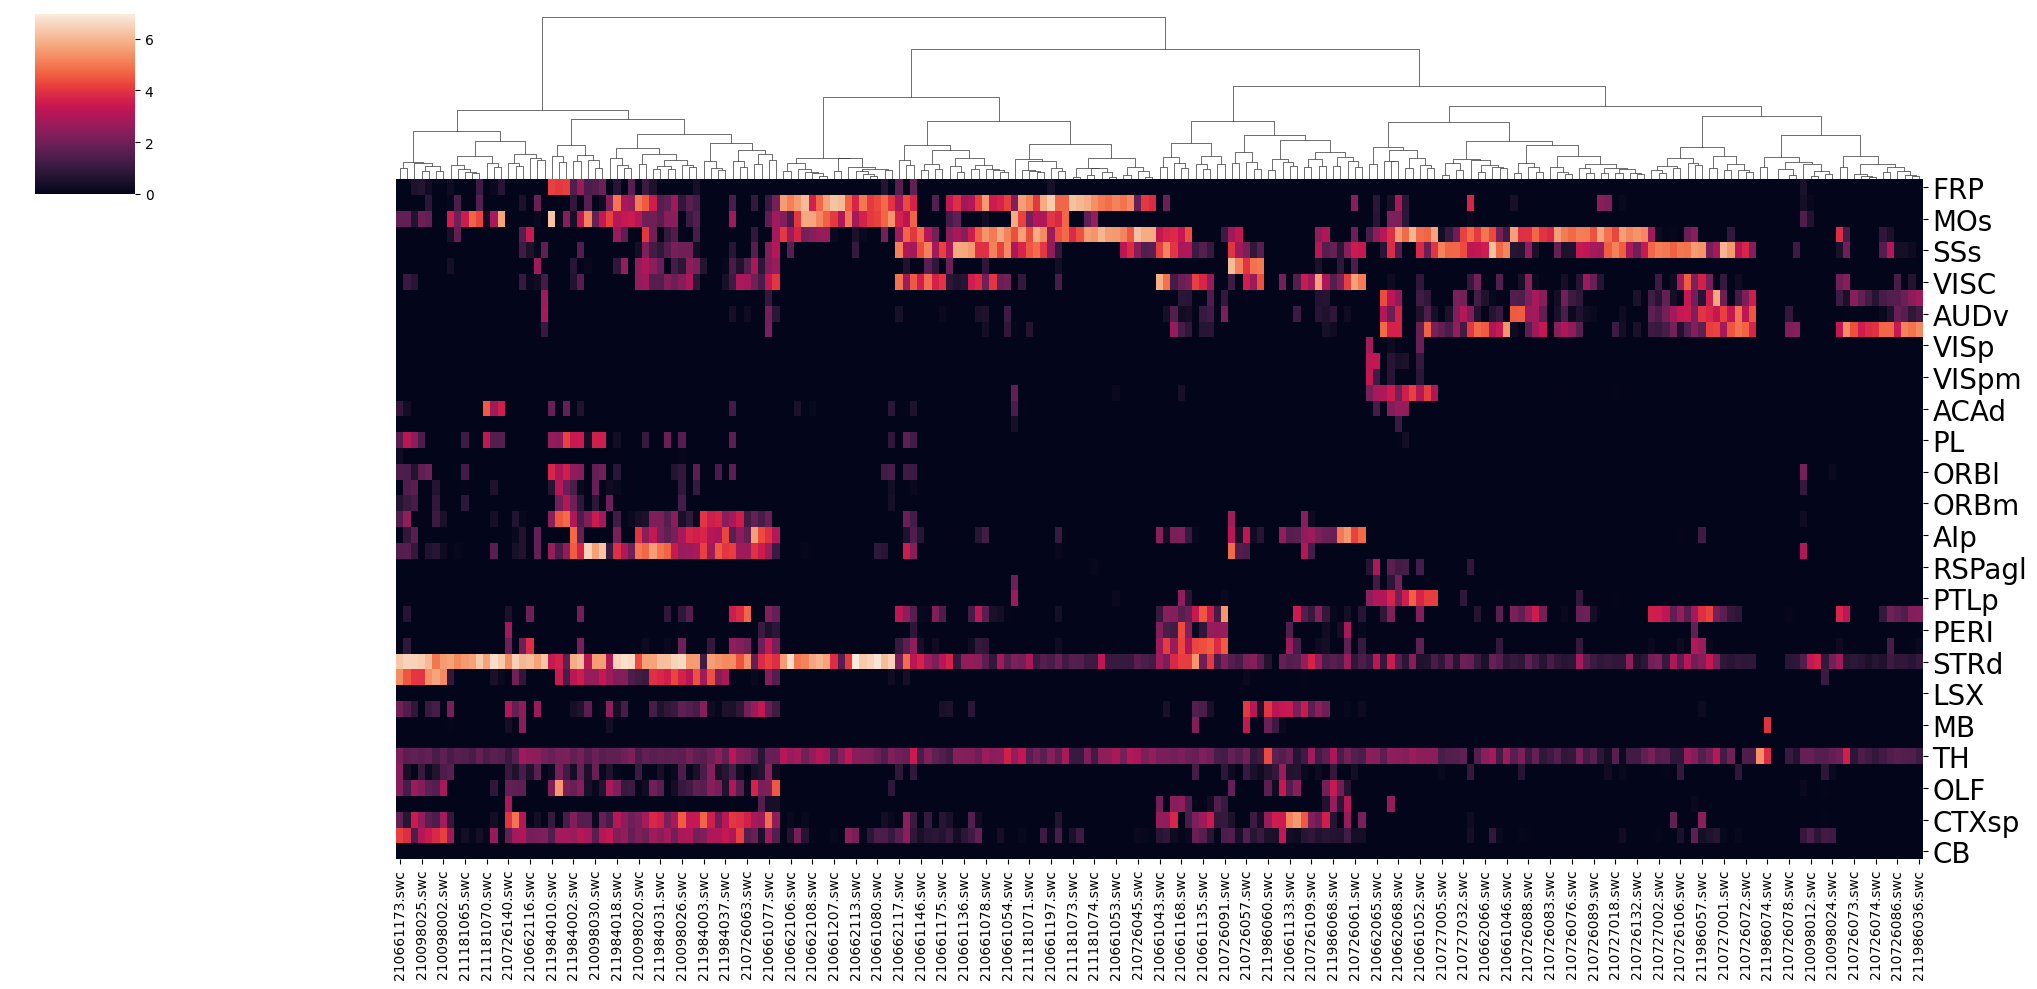

In [106]:
mat0 = np.array(propmat0)
mat0 = np.log2(mat0/1000.0+1)
# fig,ax = plt.subplots(figsize=(7,13))
df = pd.DataFrame(mat0.T,index=target_regions,columns=columes)

cg = sns.clustermap(df,figsize=[20,10],method='ward',metric='euclidean',row_cluster=False)
# plt.xticks([index+0.5 for index in range(len(target_regions))],target_regions,rotation = 90)
# plt.yticks(fontproperties='Times New Roman', size=25)
plt.setp(cg.ax_heatmap.yaxis.get_majorticklabels(), size=20)
plt.show()
# plt.yticks([])

In [170]:
df

,210661146.swc,210661206.swc,210661208.swc,210726062.swc,210726080.swc,210726131.swc,210726132.swc,210727022.swc,211181072.swc,211986068.swc,...,211986058.swc,210726063.swc,210727045.swc,210727059.swc,210726085.swc,210727004.swc,210727020.swc,210727021.swc,210727027.swc,210727028.swc
FRP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
MOp,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
MOs,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
SSp,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0
SSs,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0
GU,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
VISC,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AUDp,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AUDv,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
AUDd,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


[61.53846153846154, 26.923076923076923, 7.6923076923076925, 0.0, 0.0, 0.0, 0.0, 0.0]
[11.627906976744185, 4.651162790697675, 30.23255813953488, 16.27906976744186, 16.27906976744186, 16.27906976744186, 0.0, 0.0]
[9.75609756097561, 31.70731707317073, 34.146341463414636, 19.51219512195122, 2.4390243902439024, 0.0, 2.4390243902439024, 0.0]
[6.666666666666667, 20.0, 13.333333333333334, 40.0, 13.333333333333334, 6.666666666666667, 0.0, 0.0]


Text(0, 0.5, 'Nueron number (%)')

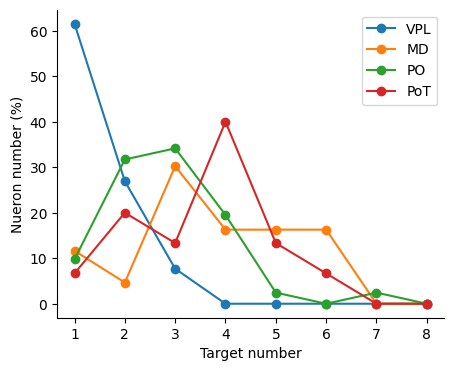

In [166]:
from collections import Counter
fig,ax = plt.subplots(figsize=(5,4))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

regionDFdict={}
for region in source_regions_sort_index:
    regionneuronname=[]
    for neuron in regionNeurons[region]:
        if neuron['sampleid']+neuron['name'] in df.columns:
            regionneuronname.append(neuron['sampleid']+neuron['name'])
    if len(regionneuronname)>0:
        regiondf = df[regionneuronname]
        regionDFdict[region]=regiondf
for region  in regionDFdict:
    # print(regionDFdict[region].shape[1],regionDFdict[region].sum(axis=0))
    if regionDFdict[region].shape[1]<15:
        continue
    projectCountsum= Counter(regionDFdict[region].sum(axis=0))
    x = range(1,9)
    y=[]
    for i in x:
        y.append(projectCountsum[i]/regionDFdict[region].shape[1]*100)
    print(y)
    plt.plot(x,y,marker='o',label=region)
plt.legend()
plt.xlabel('Target number')
plt.ylabel('Nueron number (%)')

36
[55.55555555555556, 25.0, 11.11111111111111, 5.555555555555555, 0.0, 0.0, 0.0, 0.0]
175
[9.142857142857142, 25.142857142857146, 32.0, 17.142857142857142, 7.428571428571429, 5.714285714285714, 0.5714285714285714, 0.0]


Text(0, 0.5, 'Nueron number (%)')

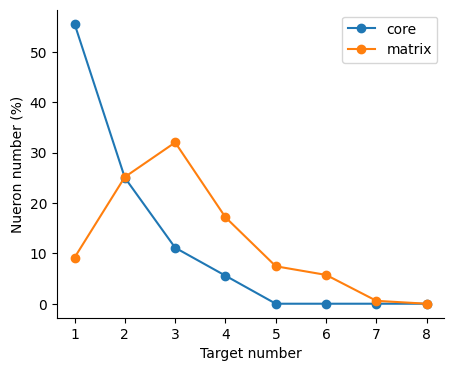

In [169]:
from collections import Counter
fig,ax = plt.subplots(figsize=(5,4))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

regionDFdict={}
coreNeuronName=[]
matrixNeuronName=[]
for region in source_regions_sort_index:
    NeuronName=[]
    regionname = 'matrix'

    for neuron in regionNeurons[region]:
        if neuron['sampleid']+neuron['name'] in df.columns:
            NeuronName.append(neuron['sampleid']+neuron['name'])


    if len(NeuronName)>0:
        if region=='VPM' or region=='VPL':
            regionname = 'core'
            coreNeuronName.extend(NeuronName)
        else:
            matrixNeuronName.extend(NeuronName)
regiondf = df[coreNeuronName]
regionDFdict['core']=regiondf
regiondf = df[matrixNeuronName]
regionDFdict['matrix']=regiondf
for region  in regionDFdict:
    print(regionDFdict[region].shape[1])
    if regionDFdict[region].shape[1]<15:
        continue
    projectCountsum= Counter(regionDFdict[region].sum(axis=0))
    x = range(1,9)
    y=[]
    for i in x:
        y.append(projectCountsum[i]/regionDFdict[region].shape[1]*100)
    print(y)
    plt.plot(x,y,marker='o',label=region)
plt.legend()
plt.xlabel('Target number')
plt.ylabel('Nueron number (%)')

In [101]:
dfT = df.T
# dfT[dfT['STRd']>3].index.tolist()
strdneuronlist = dfT.sort_values(by='STRd').index.tolist()
# target_regions = ['FRP','MOp','MOs','SSp','SSs','GU','VISC','AUDp','AUDv','AUDd','VISp','VISam','VISpm','VISa','ACAd','ACAv','PL','ILA','ORBl','ORBvl','ORBm','AIv','AIp','AId',
# 'RSPagl','RSPd','PTLp','TEa','PERI','ECT']
target_layerRegions0=[
# ['FRP1','FRP2/3','FRP5','FRP6a','FRP6b'],
['MOp1','MOp2/3','MOp5','MOp6a','MOp6b'],
['MOs1','MOs2/3','MOs5','MOs6a','MOs6b'],
# ['SSp-n1','SSp-n2/3','SSp-n4','SSp-n5','SSp-n6a','SSp-n6b'],
# ['SSp-bfd1','SSp-bfd2/3','SSp-bfd4','SSp-bfd5','SSp-bfd6a','SSp-bfd6b'],
# ['SSp-ll1','SSp-ll2/3','SSp-ll4','SSp-ll5','SSp-ll6a','SSp-ll6b'],
# ['SSp-m1','SSp-m2/3','SSp-m4','SSp-m5','SSp-m6a','SSp-m6b'],
# ['SSp-ul1','SSp-ul2/3','SSp-ul4','SSp-ul5','SSp-ul6a','SSp-ul6b'],
# ['SSp-tr1','SSp-tr2/3','SSp-tr4','SSp-tr5','SSp-tr6a','SSp-tr6b'],
# ['GU1','GU2/3','GU4','GU5','GU6a','GU6b'],
# ['VISC1','VISC2/3','VISC4','VISC5','VISC6a','VISC6b'],
# ['AUDd1','AUDd2/3','AUDd4','AUDd5','AUDd6a','AUDd6b'],
# ['AUDp1','AUDp2/3','AUDp4','AUDp5','AUDp6a','AUDp6b'],
# ['AUDpo1','AUDpo2/3','AUDpo4','AUDpo5','AUDpo6a','AUDpo6b'],
# ['AUDv1','AUDv2/3','AUDv4','AUDv5','AUDv6a','AUDv6b'],
# ['VISal1','VISal2/3','VISal4','VISal5','VISal6a','VISal6b'],
# ['VISam1','VISam2/3','VISam4','VISam5','VISam6a','VISam6b'],
# ['VISl1','VISl2/3','VISl4','VISl5','VISl6a','VISl6b'],
# ['VISp1','VISp2/3','VISp4','VISp5','VISp6a','VISp6b'],
# ['VISpl1','VISpl2/3','VISpl4','VISpl5','VISpl6a','VISpl6b'],
# ['VISpm1','VISpm2/3','VISpm4','VISpm5','VISpm6a','VISpm6b'],
# ['VISli1','VISli2/3','VISli4','VISli5','VISli6a','VISli6b'],
# ['VISpor1','VISpor2/3','VISpor4','VISpor5','VISpor6a','VISpor6b'],
# ['ACAd1','ACAd2/3','ACAd5','ACAd6a','ACAd6b'],
# ['ACAv1','ACAv2/3','ACAv5','ACAv6a','ACAv6b'],
# ['PL1','PL2','PL2/3','PL5','PL6a','PL6b'],
# ['ILA1','ILA2','ILA2/3','ILA5','ILA6a','ILA6b'],
# ['ORBl1','ORBl2/3','ORBl5','ORBl6a','ORBl6b'],
# ['ORBm1','ORBm2/3','ORBm5','ORBm6a','ORBm6b'],
# ['ORBvl1','ORBvl2/3','ORBvl5','ORBvl6a','ORBvl6b'],
['AId1','AId2/3','AId5','AId6a','AId6b'],
['AIp1','AIp2/3','AIp5','AIp6a','AIp6b'],
['AIv1','AIv2/3','AIv5','AIv6a','AIv6b'],
# ['RSPagl1','RSPagl2/3','RSPagl5','RSPagl6a','RSPagl6b'],
# ['RSPd1','RSPd2/3','RSPd5','RSPd6a','RSPd6b'],
# ['RSPv1','RSPv2/3','RSPv5','RSPv6a','RSPv6b'],
# ['VISa1','VISa2/3','VISa4','VISa5','VISa6a','VISa6b'],
# ['VISrl1','VISrl2/3','VISrl4','VISrl5','VISrl6a','VISrl6b'],
# ['TEa1','TEa2/3','TEa4','TEa5','TEa6a','TEa6b'],
# ['PERI1','PERI2/3','PERI5','PERI6a','PERI6b'],
# ['ECT1','ECT2/3','ECT5','ECT6a','ECT6b']

]
target_layerRegions=[]
for regions in target_layerRegions0:
    for region in regions:
        target_layerRegions.append(region)
propmat0=[]
columes =  []

for neuron in strdneuronlist:
        print(neuron)
        property = iondata.getNeuronPropertyByID(neuron[0:6], neuron[6:])
        brproperty=BR.RegionProperty(copy.deepcopy(br))
        brpropertyLeft=BR.RegionProperty(copy.deepcopy(br))
        brpropertyRight=BR.RegionProperty(copy.deepcopy(br))
        brproperty.setProperty(property['projectregion'])
        brpropertyLeft.setProperty(property['projectleftregion'])
        brpropertyRight.setProperty(property['projectrightregion'])
        prop=[]
        for targetRegion in target_layerRegions:
            regionsum = brproperty.getSumProperty(targetRegion)
            regionleft = brpropertyLeft.getSumProperty(targetRegion)
            regionright = brpropertyRight.getSumProperty(targetRegion)
            ipsi=0
            contra=0
            if property['somapoint'][2]<5700:
                ipsi=regionleft
                contra=regionright
            else:
                ipsi=regionright
                contra=regionleft
            prop.append(ipsi)
        if np.array(prop).sum()>10:
            columes.append(neuron[0:6]+neuron[6:])
            propmat0.append(prop)
mat0 = np.array(propmat0)
mat0 = np.log2(mat0/1000.0+1)
# fig,ax = plt.subplots(figsize=(7,13))
dfstrd = pd.DataFrame(mat0.T,index=target_layerRegions,columns=columes)

210727022.swc
211986074.swc
210098019.swc
211984026.swc
210726105.swc
210726069.swc
210662066.swc
210726132.swc
210726077.swc
210661052.swc
210661172.swc
211986060.swc
210726075.swc
210726066.swc
210661171.swc
210726074.swc
210726068.swc
210726079.swc
210727003.swc
210727031.swc
210726078.swc
210726123.swc
210662070.swc
210726076.swc
210661046.swc
210726072.swc
210726073.swc
210727001.swc
210727028.swc
210726085.swc
210726061.swc
210727056.swc
210727018.swc
210726086.swc
210727030.swc
210661154.swc
210727005.swc
210726067.swc
210661042.swc
210726070.swc
210727020.swc
210098023.swc
210661057.swc
211986036.swc
211986037.swc
210727027.swc
210661047.swc
210727004.swc
210726082.swc
210726084.swc
210662115.swc
210661053.swc
210661050.swc
210661180.swc
210661208.swc
211181074.swc
211986056.swc
210726089.swc
210661206.swc
210726065.swc
210662071.swc
211984003.swc
210662072.swc
210662067.swc
210726083.swc
210661215.swc
210726059.swc
210661197.swc
210661049.swc
210661130.swc
211986066.swc
211986

In [114]:
dfstrd

,210662070.swc,210727028.swc,210726061.swc,210661154.swc,210661042.swc,210661057.swc,210727027.swc,210661047.swc,210726082.swc,210662115.swc,...,211984020.swc,210661079.swc,211984030.swc,210098026.swc,210098027.swc,210662106.swc,210098029.swc,210098011.swc,210661080.swc,210662113.swc
MOp1,0.000000,0.000000,0.194202,0.000000,0.000000,1.760780,0.00000,0.116789,0.150847,3.031841,...,0.000000,0.000000,0.000000,0.000000,0.106243,0.511764,0.000000,0.000000,0.567445,0.213376
MOp2/3,0.000000,0.138501,2.120281,2.242679,2.889737,3.154210,1.44077,4.259249,0.315458,4.699280,...,0.000000,0.220730,0.000000,0.000000,0.493027,2.769659,0.000000,0.000000,2.309120,1.345627
MOp5,0.000000,0.000000,0.736234,0.585784,1.566430,1.652817,1.53212,3.290211,0.000000,2.498302,...,0.000000,3.655711,1.636448,0.000000,1.414187,4.044874,0.000000,0.175525,3.360560,2.665692
MOp6a,0.777202,0.000000,0.000000,0.114478,1.515069,1.447750,0.00000,1.237010,0.000000,0.670260,...,0.000000,2.370629,2.153700,0.669605,1.940672,3.558256,0.000000,2.713090,2.525019,2.648079
MOp6b,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.437253,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.363403,0.284962,0.427744,0.000000,1.006805,0.261077,0.110166
MOs1,0.000000,0.000000,0.000000,0.000000,0.000000,0.879356,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.284180,0.000000,0.000000,0.561686,0.461399,1.393488,0.000000,0.590465,0.000000
MOs2/3,0.039107,0.000000,0.000000,0.000000,0.000000,0.556429,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.509458,0.104315,0.000000,1.218341,0.032292,1.491728,2.092790,2.652490,0.000000
MOs5,0.000000,0.000000,0.000000,0.000000,0.000000,0.957662,0.00000,0.000000,0.000000,0.000000,...,0.635218,3.589951,1.487002,0.000000,2.151592,1.078032,1.332649,2.288544,3.394047,2.025325
MOs6a,0.759987,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,2.221889,1.801850,0.000000,2.387420,0.000000,1.147128,1.584152,1.425647,1.840889
MOs6b,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.276604,0.000000,0.000000,0.564503,0.000000,0.196605,0.000000,0.360114,0.265233


In [129]:
mat0 = np.array(propmat0)
mat0 = np.log10(mat0/1000.0+1)
# fig,ax = plt.subplots(figsize=(7,13))
dfstrd = pd.DataFrame(mat0.T,index=target_layerRegions,columns=columes)
fig,ax = plt.subplots(figsize=(10,10))

sns.heatmap(dfstrd.T)
sum=0
for regions in target_layerRegions0:
    sum+=len(regions)
    plt.axvline(x=sum,ls="-",c="white", linewidth=0.5)


ValueError: Shape of passed values is (43, 211), indices imply (25, 211)

In [108]:
from collections import Counter
threshold=2
mat0 = np.array(propmat0)
mat0 = np.log2(mat0/1000.0+1)
mat0[mat0>threshold]=threshold
mat0[mat0<threshold]=0
mat0.shape

(211, 43)

([<matplotlib.patches.Wedge at 0x2b5fdca49d0>,
 [Text(1.0956135705106598, 0.09813716988421803, '0'),
  Text(0.8308368174946787, 0.7209092749405531, '1'),
  Text(-0.4971993683827017, 0.9812200507938281, '2'),
  Text(-0.9197026965844269, -0.6034458964110484, '3'),
  Text(0.4076766022408429, -1.0216652034719405, '4'),
  Text(0.9539898684271207, -0.5476343040190278, '5'),
  Text(1.0824892744009262, -0.19549161313712834, '6'),
  Text(1.0998780768653273, -0.01637730231232053, '7')],
 [Text(0.5976074020967234, 0.053529365391391644, '2.8%'),
  Text(0.4531837186334611, 0.39322324087666527, '17.1%'),
  Text(-0.2711996554814736, 0.5352109367966335, '25.1%'),
  Text(-0.5016560163187782, -0.3291523071332991, '28.4%'),
  Text(0.22236905576773247, -0.5572719291665129, '15.2%'),
  Text(0.5203581100511567, -0.29870962037401516, '6.2%'),
  Text(0.5904486951277779, -0.10663178898388817, '4.7%'),
  Text(0.5999334964719967, -0.008933073988538471, '0.5%')])

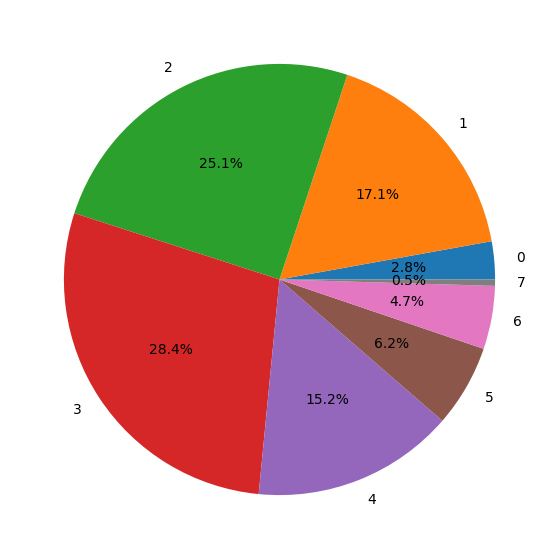

In [131]:
from collections import Counter
threshold=3
mat0 = np.array(propmat0)
mat0 = np.log2(mat0/1000.0+1)
mat0[mat0>threshold]=threshold
mat0[mat0<threshold]=0
mat0=mat0/threshold
df = pd.DataFrame(mat0.T,index=target_regions,columns=columes)
# sns.heatmap(df)
projectCount = mat0.sum(1)
projectCountsum= Counter(projectCount)
projectCountsumdict=dict(projectCountsum)
projectCountsumdict = dict([(k,projectCountsumdict[k]) for k in sorted(projectCountsumdict.keys())])
projectCountsumdict
# print(propmat0)
# del projectCountsumdict[0.0]
labels = np.array(list(projectCountsumdict.keys())).astype(np.int8).tolist()
# projectCountsumdict.values()
fig,ax = plt.subplots(figsize=(7,7))
plt.pie(projectCountsumdict.values(),labels=labels,autopct = '%1.1f%%')

In [25]:
df.to_csv('../resource/thsample/matrixdf.csv')

In [21]:
from scipy.cluster.hierarchy import linkage ,fcluster,fclusterdata,dendrogram
from scipy import spatial

from sklearn.cluster import AgglomerativeClustering



211


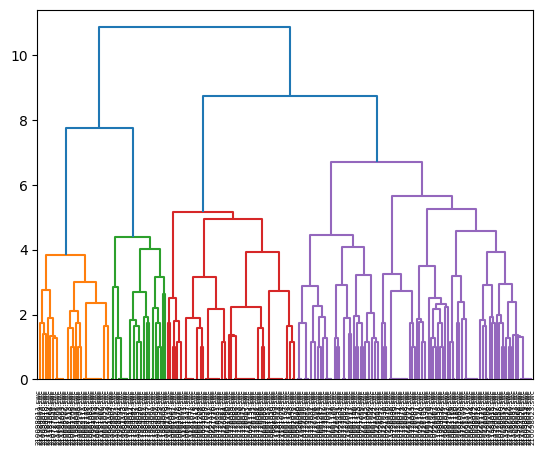

In [25]:
def fclusterDF(dataframe):
		matData =  dataframe.values[:,:].transpose()
		distance = spatial.distance.pdist(matData.astype(float))
		linkresult = linkage(distance,method='ward',metric='euclidean')
		
		cluster=fcluster(linkresult,t=4.4,criterion='inconsistent',depth=25,R=None,monocrit=None)#这个需要先计算linkage，再出结果
		dendrogram(linkresult,labels=dataframe.columns[:])
		return cluster
clusterproject = fclusterDF(df)
print(len(clusterproject))
# ac = AgglomerativeClustering(n_clusters=3, affinity='euclidean', linkage='ward')
# clustering = ac.fit(df)
# print("每个数据所属的簇编号", clustering.labels_,len(clustering.labels_))
# print("每个簇的成员", clustering.children_,len(clustering.children_))

In [ ]:
regionNeurons['VPM']

In [21]:
import Visual as nv

# neuronvis = nv.neuronVis(renderModel=0)
# neuronvis.render.setBackgroundColor((1.0,1.0,1.0,1.0))
# neuronvis.render.setView('dorsal')
# neuronsarray =np.array(df.columns)

for i in range(max(clusterproject)):
    neurons = df.columns[clusterproject==(i+1)]
    
    neuronscene=[]
    for neuron in neurons:
        scene={}
        scene['sampleid']= neuron[0:6]
        scene['name']=neuron[6:]
        neuronscene.append(scene)
    Scene.createScene(neuronscene,'../resource/thsample/matrix/thmatrixclusterWithSTR'+str(i+1)+'.nv')
    
    # for neuron in neurons:
    #     neuronT = iondata.getNeuronTreeByID(neuron[0:6], neuron[6:])
    #     neuronvis.addNeuronTree(neuronT,neuron,somaColor=[1,0,0],axonColor=[1,0,0],dendriteColor=[1,0,0])
    # neuronvis.render.savepng("../resource/thsample/matrix/cluster"+str(i+1)+'.png')
    # neuronvis.clear()

[[  0.      0.      0.    ...   0.      0.      0.   ]
 [  0.      0.    378.446 ...   0.      0.      0.   ]
 [  0.      0.      0.    ...   0.      0.      0.   ]
 ...
 [  0.      0.      0.    ...   0.      0.      0.   ]
 [  0.      0.      0.    ...   0.      0.      0.   ]
 [  0.      0.      0.    ...   0.      0.      0.   ]]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


d:\Program Files\anaconda3\envs\neuronVis\lib\site-packages\seaborn\matrix.py:654: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


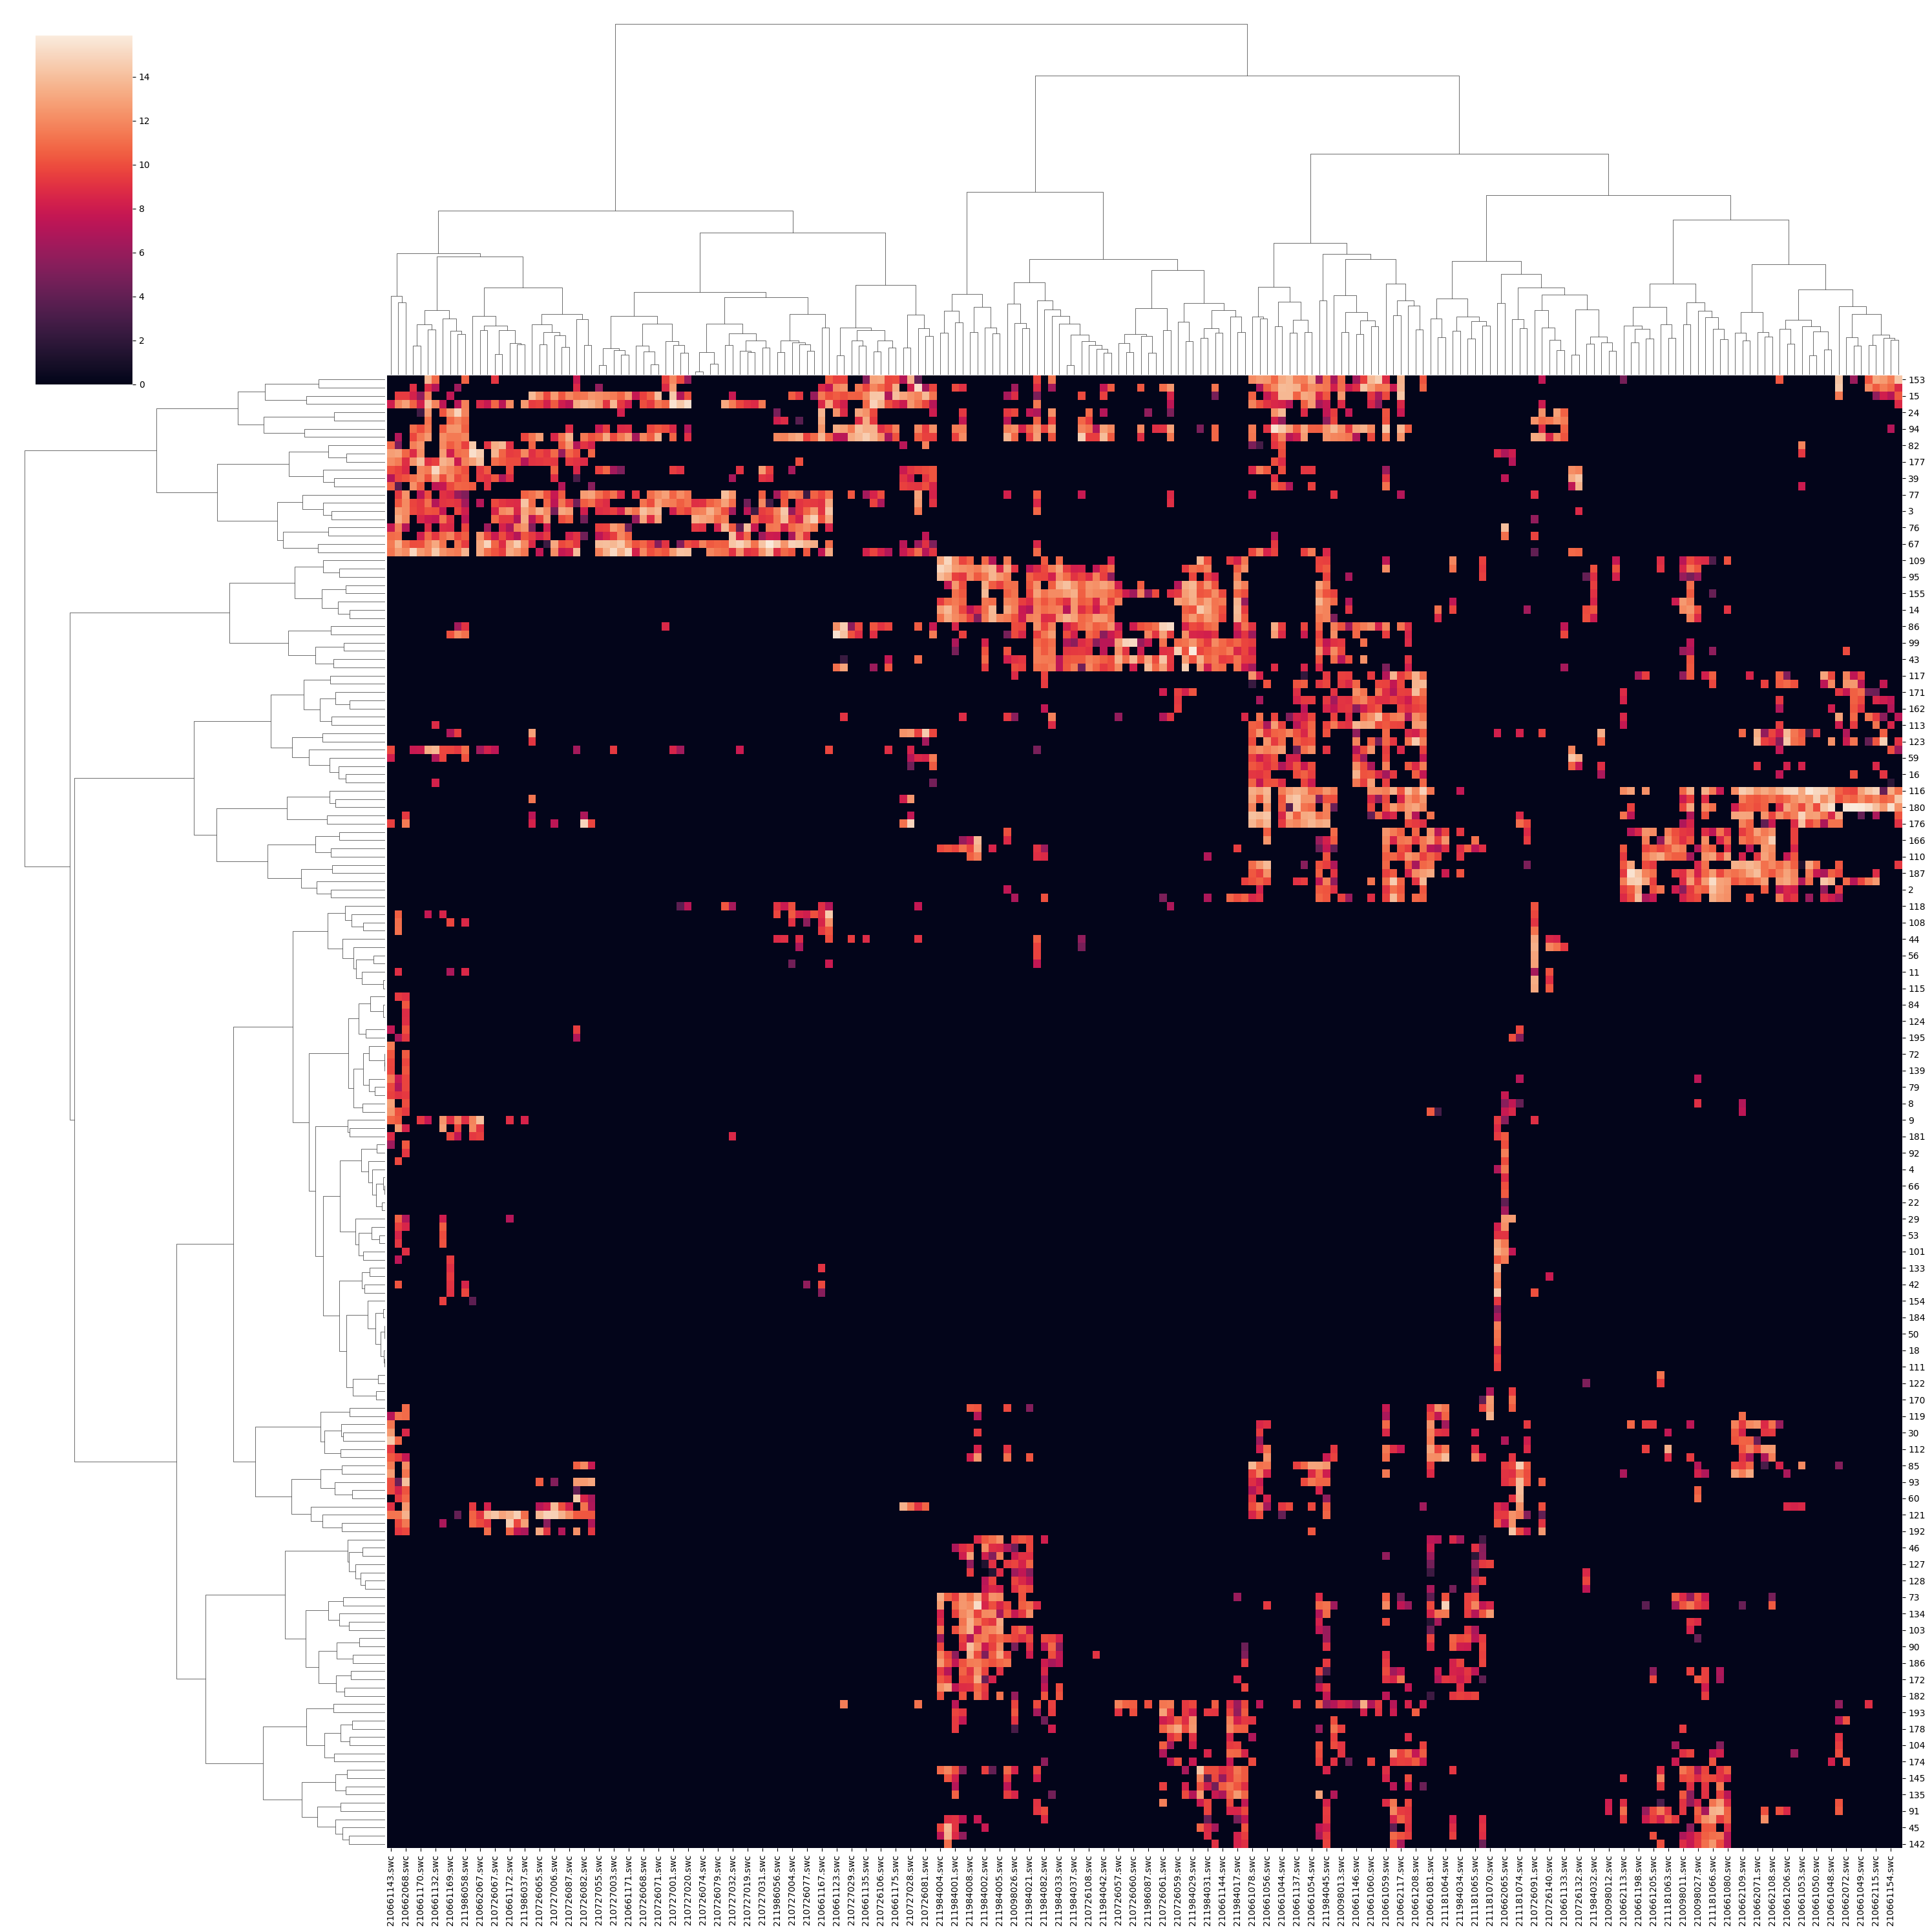

In [175]:

import matplotlib
import matplotlib.pyplot as plt
matplotlib.use('module://matplotlib_inline.backend_inline')
%matplotlib inline
color=[[255,0,0],[0,255,0],[0,0,255],[128,128,128],[255,0,255],[60,255,175],[255,155,0],[105,155,55],[155,155,205],[132,191,150],[]]
isoprojectmat=[]
columes2=[]
for region,neuronsInRegion in regionNeurons.items():
    # if region=='VPM' or region=='VPL':
    #     continue
    for neuron in neuronsInRegion:
        
        # property = iondata.getNeuronPropertyByID(neuron['sampleid'], neuron['name'])
        path = "../resource/swc/"+neuron['sampleid']+"/"+neuron['name']+"isoprojection.json"
        # print(path)
        csv_array = np.loadtxt(path,dtype=str)
        temp = np.zeros(200)

        if len(csv_array)>2:
            # print(csv_array,len(csv_array))
            for key,val in csv_array:
                temp[int(key)]=val
        temp[0]=0
        # temp[103]=0
        if temp.sum()<10:
            continue
        columes2.append(neuron['sampleid']+neuron['name'])
        isoprojectmat.append(temp)

isoproject = np.array(isoprojectmat)
print(isoproject)
isoproject = np.log2(isoproject/1.0+1)
print(isoproject[:,0])
df = pd.DataFrame(isoproject.T,columns=columes2)
df = df[df.any(axis=1)]
sns.clustermap(df,figsize=[30,30],method='ward',metric='euclidean',row_cluster=True)

In [183]:
print(df.index.to_list())

[2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 35, 36, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 59, 60, 61, 62, 63, 65, 66, 67, 68, 70, 71, 72, 73, 74, 75, 76, 77, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 127, 128, 129, 131, 132, 133, 134, 135, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 148, 149, 150, 151, 152, 153, 154, 155, 157, 158, 159, 160, 161, 162, 164, 166, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 198, 199]


d:\Program Files\anaconda3\envs\neuronVis\lib\site-packages\seaborn\matrix.py:654: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


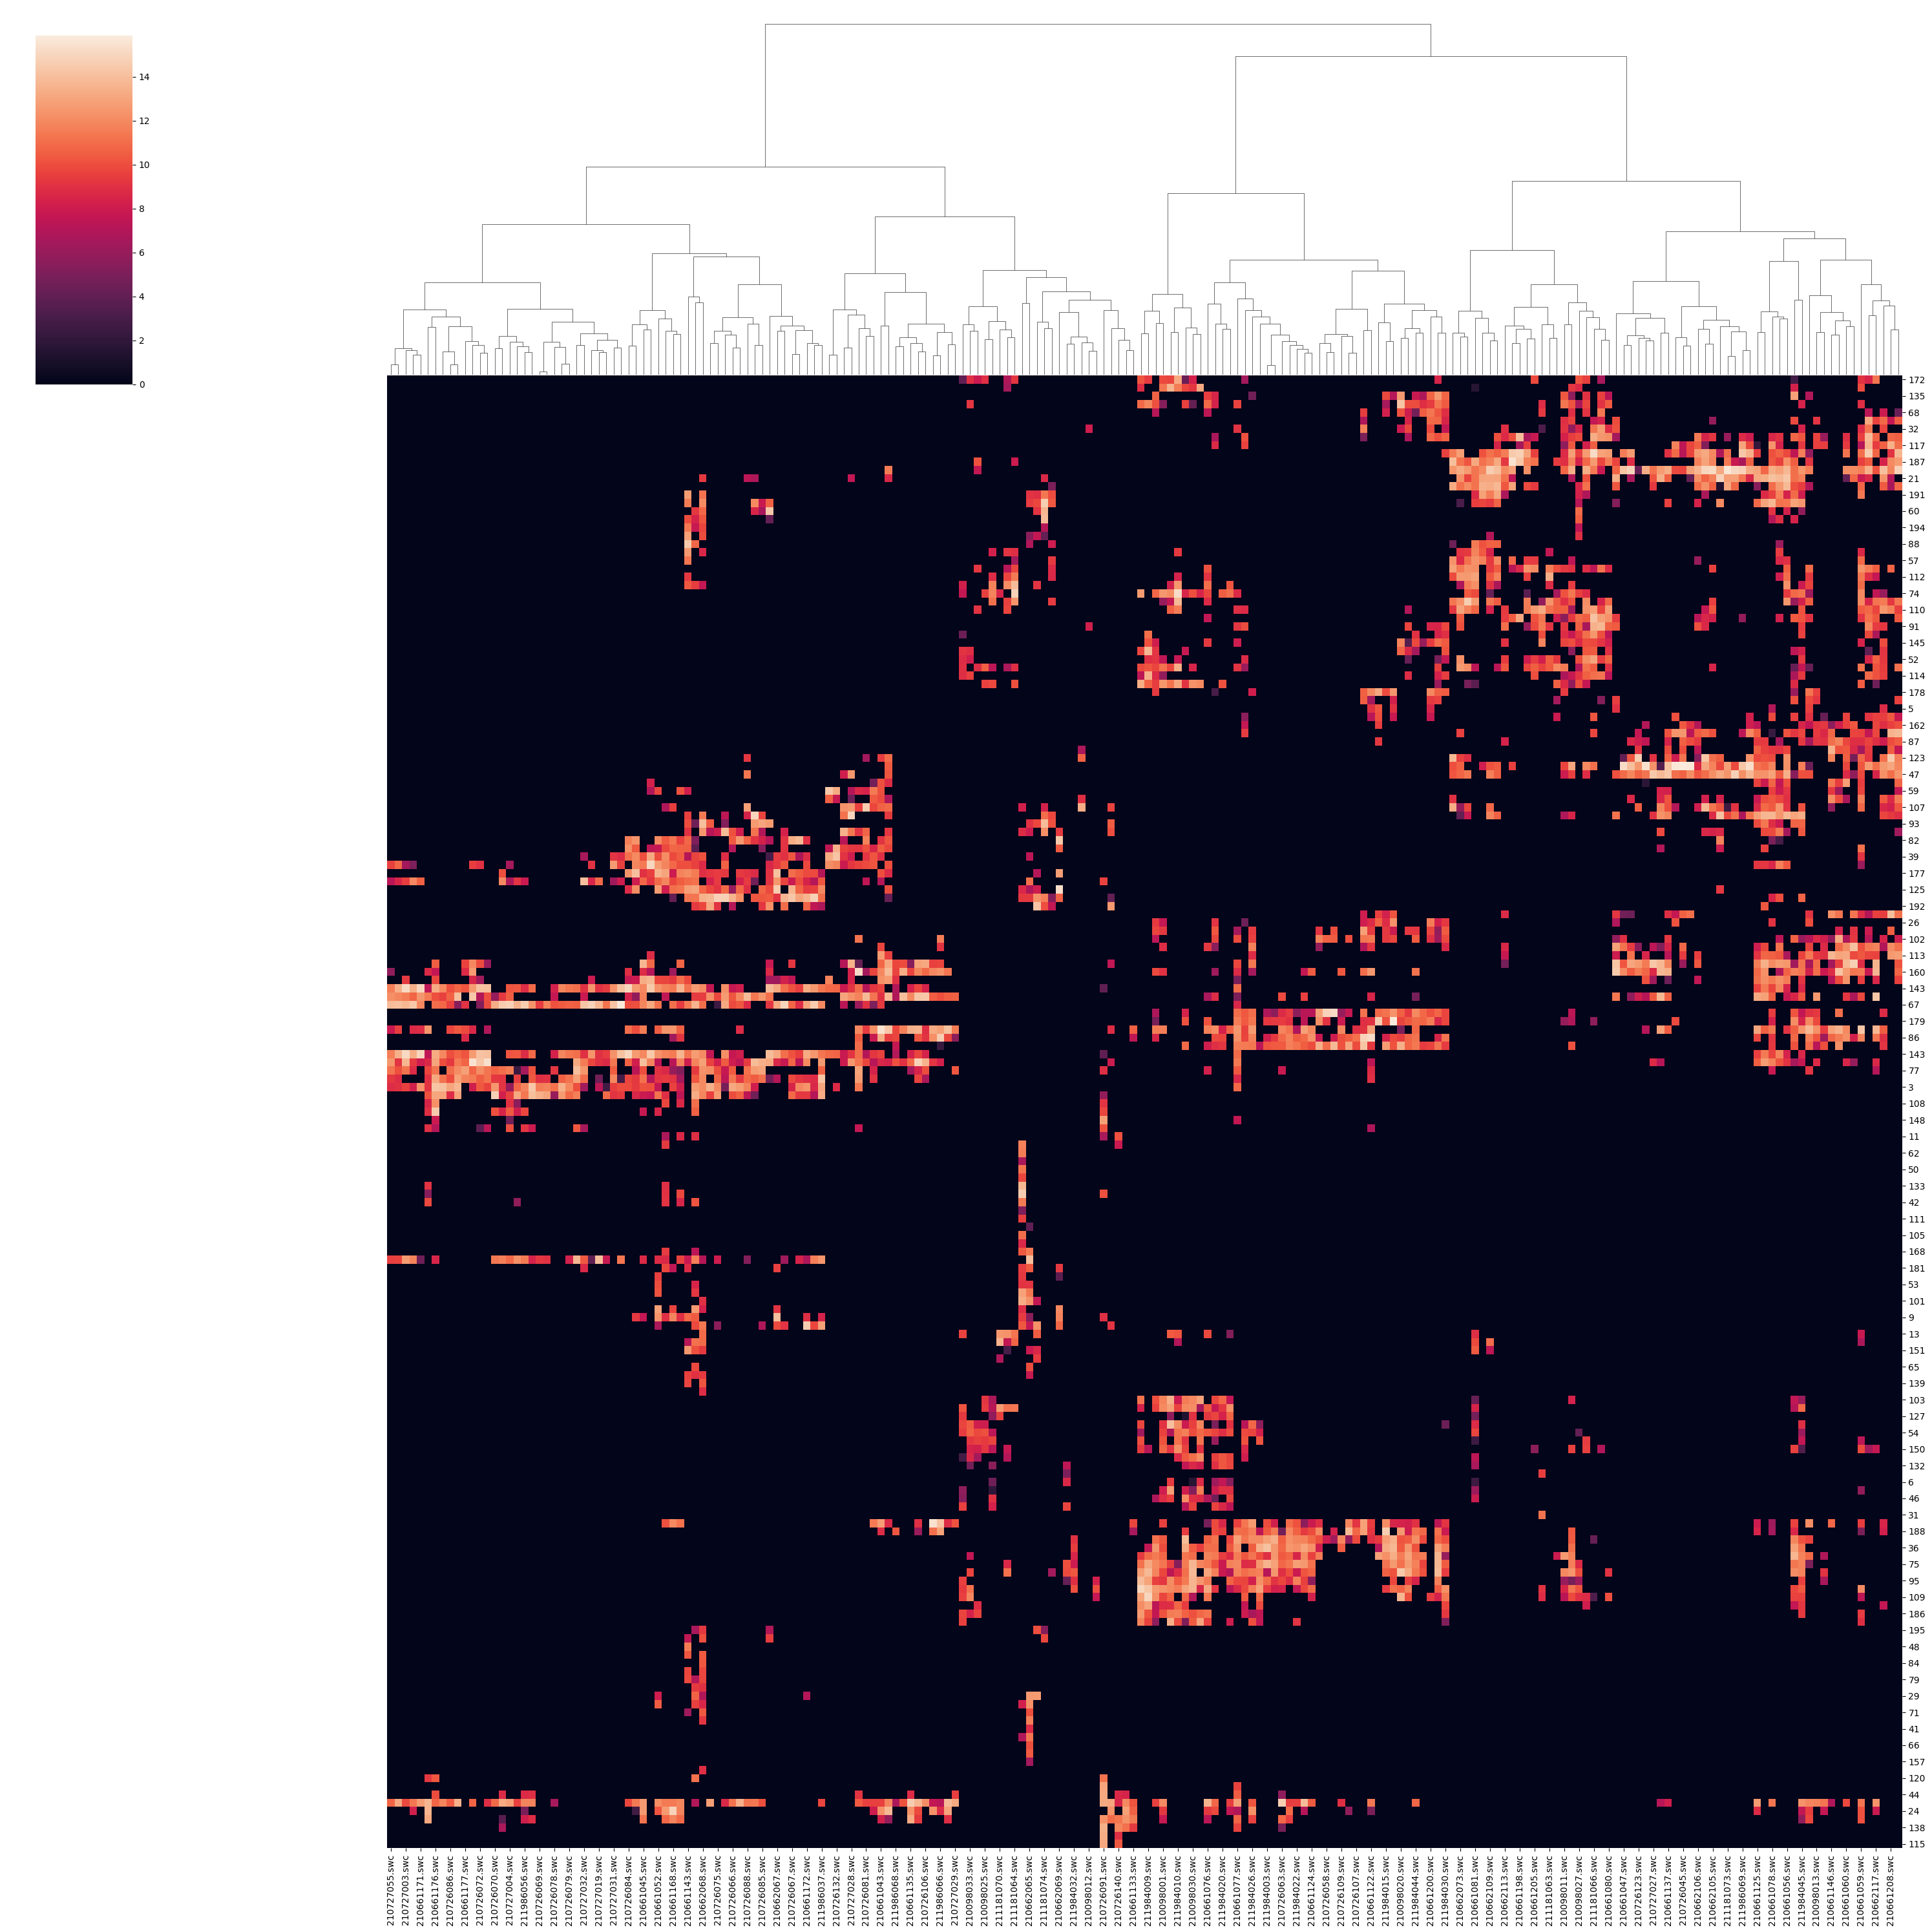

In [176]:
regionindex=[
    [172,20],#FRP
    [135,83,68,40,32,183,117,55,187,116,21,149,191,85,60],#MOp
[28,194,8,88,30,57,89,112,199,74,166,110,2,91,142,145,45,52,25,114,73],#MOs
    [178,104,5,174,162,131,87,16,123,180,47,164,59,63,107,176,93,12,82,175,39,161,177,146,125,121,192], #ssp
[171,26,193,102,61,113,153,160,35,143,15,67],#SSs
[99,179],#GU
[94,86,43],#VISC
[143,97,77,190,3,49,108,169,148,118],#AUD
[11,173,62,184,50,38,133,189,42,96,111,22,105,18,168,76,181,154,53,185,101,129,9,51],#VIS
[13,119,151,137,65,159,139,27],#ACA
[103,134,127],#PL
[90,54,182,150,70,132,122,6,198,46,128,31],#ORB

[98,188,155,36,80,75,14,95,33,109,10,186,158],#AI
[195,140,48,72,84,17,79,152,29,141,71,92,41,4,66,106,157,124], #RSP
[120,56,44,144],#TEa
[24,81,138,19,115],#ECT/PERI






]
columnsLabels=['FRP','MOp','MOs','SSp','SSs','GU','VISC','AUD','VIS','ACA','PL','ORB','AI','RSP','TEa','ECT']
indextemp=[]
for i in range(len(regionindex)):
    for j in range(len(regionindex[i])):
        indextemp.append(regionindex[i][j])
df2= df.reindex(indextemp)
sns.clustermap(df2,figsize=[30,30],method='ward',metric='euclidean',row_cluster=False)

# sum=0
# for i in range(len(regionNeuronCount)):
#     index  = i
#     if regionNeuronCount[index]>0:
#         sum+=regionNeuronCount[index]
#         plt.axhline(y=sum,ls="-",c="white", linewidth=0.5)
plt.axvline(x=10,ls="-",c="blue", linewidth=1.5)
plt.savefig('../resource/isocluster.svg')


2 Rectangle(xy=(0.1, 53.4), width=0.1, height=0.6, angle=0) #B3EE3A
15 Rectangle(xy=(0.1, 48.9), width=0.1, height=4.5, angle=0) #006400
21 Rectangle(xy=(0.1, 42.6), width=0.1, height=6.3, angle=0) #F00
27 Rectangle(xy=(0.1, 34.5), width=0.1, height=8.1, angle=0) #00F
12 Rectangle(xy=(0.1, 30.9), width=0.1, height=3.6, angle=0) #8B6508
2 Rectangle(xy=(0.1, 30.3), width=0.1, height=0.6, angle=0) #CD6839
3 Rectangle(xy=(0.1, 29.4), width=0.1, height=0.9, angle=0) #F0F
10 Rectangle(xy=(0.1, 26.4), width=0.1, height=3, angle=0) #FFFACD
24 Rectangle(xy=(0.1, 19.2), width=0.1, height=7.2, angle=0) #FF1493
8 Rectangle(xy=(0.1, 16.8), width=0.1, height=2.4, angle=0) #FFE1FF
3 Rectangle(xy=(0.1, 15.9), width=0.1, height=0.9, angle=0) #CFCFCF
12 Rectangle(xy=(0.1, 12.3), width=0.1, height=3.6, angle=0) #90EE90
13 Rectangle(xy=(0.1, 8.4), width=0.1, height=3.9, angle=0) #B4CDCD
18 Rectangle(xy=(0.1, 3), width=0.1, height=5.4, angle=0) #6E7B8B
4 Rectangle(xy=(0.1, 1.8), width=0.1, height=1.2, angl

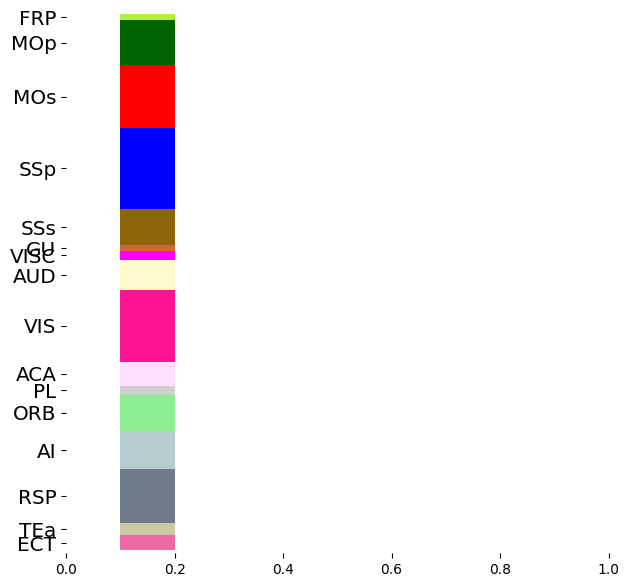

In [177]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111)
ax.set_ylim(0,54)
ax.set_xlim(0,1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
start=0

labelstemp =[]
yindex =[]
for i in range(len(regionindex)):
    columns = regionindex[i]
    # print(columns)
    
    clustercenter = 54-0.3*len(columns)/2-start
    yindex.append(54-0.3*len(columns)/2-start)

    rect = plt.Rectangle((0.1,54-0.3*len(columns)-start),0.1,0.3*len(columns),facecolor=rgbToHex(source_regions_color[i][0],source_regions_color[i][1],source_regions_color[i][2]))
    # rect.set_facecolor(rgbToHex(color[i][0],color[i][1],color[i][2]))
    print(len(columns),rect,rgbToHex(source_regions_color[i][0],source_regions_color[i][1],source_regions_color[i][2]))
    start=start+0.3*len(columns)
    ax.add_patch(rect)
    pass
# rect = plt.Rectangle((0.1,4.1),0.5,0.3)
# print(rect)
# ax.add_patch(rect)
# plt.xticks([])
print(yindex,labelstemp)
plt.yticks(yindex,columnsLabels,rotation = 0,fontsize='x-large')

# plt.axis('off')
plt.savefig('../resource/regionbar.svg')
plt.show()


204 8 [8 8 8 8 1 3 3 8 3 8 8 2 2 2 1 1 1 1 2 2 1 1 1 3 2 4 2 1 2 2 3 8 1 4 1 6 4
 6 6 6 6 6 7 7 7 8 8 7 4 8 6 4 6 7 4 4 5 4 6 6 8 7 4 7 4 5 5 6 5 5 5 5 5 6
 7 6 6 6 6 4 6 4 8 6 6 8 6 8 4 4 4 8 3 3 2 1 8 8 8 8 8 8 8 8 6 3 6 8 8 8 6
 2 2 2 1 2 2 8 7 7 6 4 2 2 4 7 8 8 3 6 5 4 7 6 6 6 3 6 1 1 1 2 1 1 1 4 1 1
 1 2 1 1 1 1 1 3 7 7 7 8 8 7 7 7 7 7 4 4 8 2 8 8 2 2 1 2 4 3 4 8 3 4 3 3 1
 3 1 8 6 6 6 8 3 2 6 7 7 2 1 2 1 2 8 3]


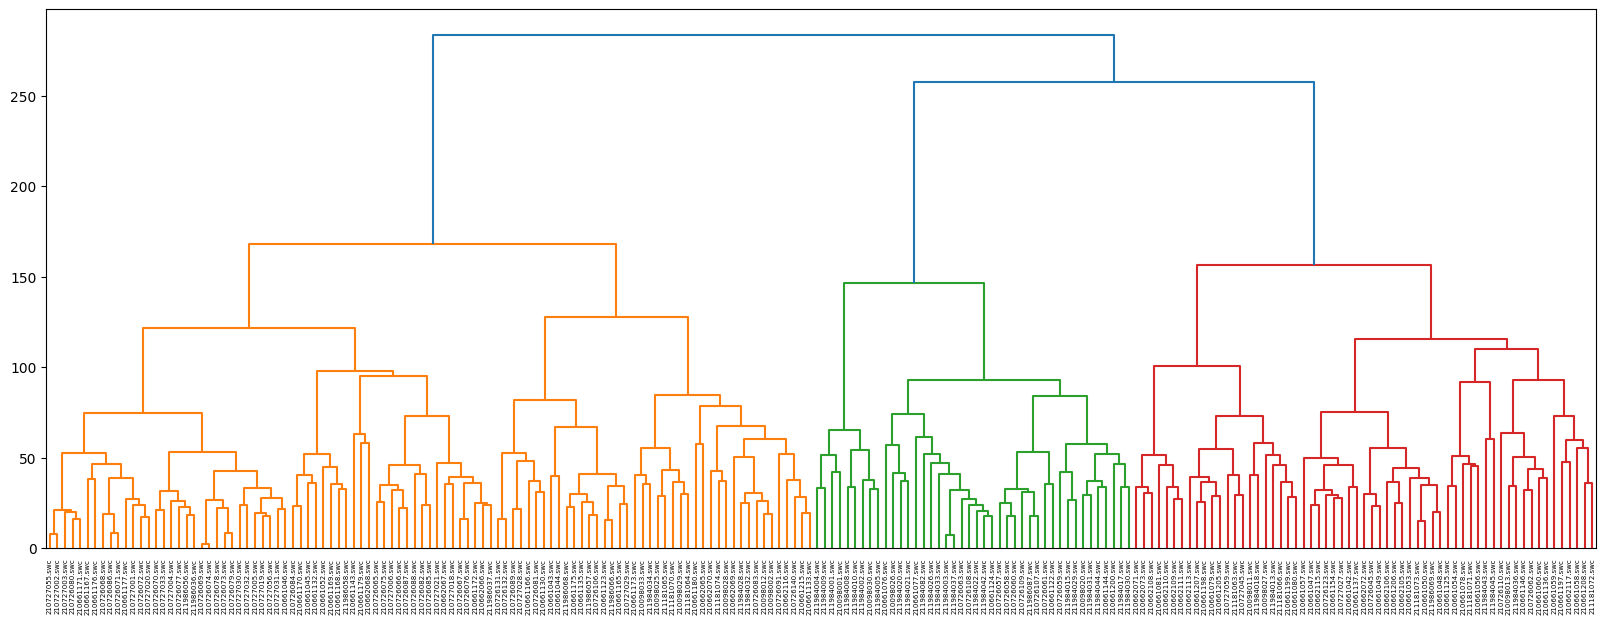

In [178]:
import Scene
fig,ax = plt.subplots(figsize=(20,7))
def fclusterDF2(dataframe):
		matData =  dataframe.values[:,:].transpose()
		distance = spatial.distance.pdist(matData.astype(float))
		linkresult = linkage(distance,method='ward',metric='euclidean')
		
		cluster=fcluster(linkresult,t=3.5,criterion='inconsistent',depth=25,R=None,monocrit=None)#这个需要先计算linkage，再出结果
		dendrogram(linkresult,labels=dataframe.columns[:])
		return cluster
cluster = fclusterDF2(df2)
print(len(cluster),np.max(cluster),cluster)


for i in range(np.max(cluster)):
	columns = df.columns[cluster==(i+1)]
	neurons = []
	for j in range(len(columns)):
		property = iondata.getNeuronPropertyByID(neuron['sampleid'], neuron['name'])
		if property['somaregion'] not in source_regions_sort_index:
			pass
		neuron={}
		neuron['sampleid']=columns[j][0:6]
		neuron['name']=columns[j][6:]
		# neuron['color']=source_regions_color[source_regions_sort_index.index(property['somaregion'])]
		neuron['color']=color[i]
		neuron['soma']=property['somaregion']
		neurons.append(neuron)
	# print(i,neurons)
	Scene.createScene(neurons,'../resource/thsample/matrix/thisocluster-'+str(i+1)+'.nv')

0.6523039825025686

1.1208963221503414


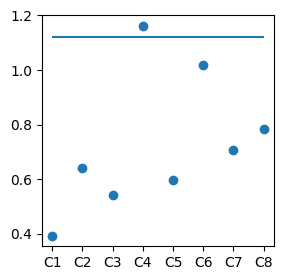

In [24]:
import random
fig,ax = plt.subplots(figsize=(3,3))
somadist=[]
allsomas=None
for i in range(np.max(cluster)):
	columns = df.columns[cluster==(i+1)]
	neuronsomas = []
	for j in range(len(columns)):
		neuron={}
		neuron['sampleid']=columns[j][0:6]
		neuron['name']=columns[j][6:]
		property = iondata.getNeuronPropertyByID(neuron['sampleid'], neuron['name'])
		neuronsomas.append( property['somapoint'] )
	somas = np.array(neuronsomas)
	if allsomas is None:
		allsomas = somas
	else:
		allsomas= np.vstack([allsomas,somas])
	sum=0
	for neuronsoma1 in somas:
		for neuronsoma2 in somas:
			dist = np.sqrt(np.sum(np.square(neuronsoma1 - neuronsoma2)))
			# print(dist,len(somas))
			sum+=dist/1000
	somadist.append(sum/len(somas)/len(somas))

#get 10 random soma points
randomSomas=[]
averageDist=[]
times=10
for j in range(times):
	for i in range(10):
		randomindex=int(random.random()*len(allsomas))
		# print(randomindex)
		randomSomas.append(allsomas[randomindex])
	sum=0
	for neuronsoma1 in randomSomas:
		for neuronsoma2 in randomSomas:
			dist = np.sqrt(np.sum(np.square(neuronsoma1 - neuronsoma2)))
			# print(dist,len(somas))
			sum+=dist/1000
	averageDist.append(sum/len(randomSomas)/len(randomSomas))

print(np.array(averageDist).mean())
plt.scatter( range(1,np.max(cluster)+1),somadist)
label=[]
for i in range(1,np.max(cluster)+1):
	label.append('C'+str(i))
plt.xticks(range(1,np.max(cluster)+1),label)
plt.hlines(y=np.array(averageDist).mean(),xmin=1,xmax=8)

In [63]:
df

,210661146.swc,210661206.swc,210661208.swc,210726062.swc,210726080.swc,210726131.swc,210726132.swc,211181072.swc,211986068.swc,210661154.swc,...,210726063.swc,210727045.swc,210727059.swc,210726085.swc,210727004.swc,210727006.swc,210727020.swc,210727021.swc,210727027.swc,210727028.swc
2,0.0,8.567751,0.000000,0.000000,0.000000,0.0,0.000000,10.270786,0.0,0.0,...,0.0,8.049032,11.26092,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0
3,0.0,0.000000,0.000000,0.000000,8.294005,0.0,8.729505,0.000000,0.0,0.0,...,0.0,0.000000,0.00000,0.0,5.957942,4.756933,9.641495,0.000000,0.0,0.0
4,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.000000,0.00000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0
5,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.000000,0.00000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0
6,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.000000,0.00000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,0.0,0.000000,10.510191,8.271552,0.000000,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.000000,0.00000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0
194,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.000000,0.00000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0
195,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.000000,0.00000,0.0,0.000000,0.000000,0.000000,6.948239,0.0,0.0
198,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.000000,0.00000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0


[7646.05822754 3956.74108887 3546.13989258]
[7555.97034144 3869.04918981 3762.70587384]
[7676.4906684  4019.6187066  3849.43185764]
[7270.2014974  3892.89176432 4597.73551432]
[6845.05251736 4054.21657986 5697.09722222]
[7391.91903409 4187.98958333 5032.37085701]
[7056.06480824 4103.9428267  4880.60209517]
[7245.06700721 4081.45562901 4405.67588141]
[7375.86554075 4024.5965648  4368.83176317]
[0.0, 0.1875, 0.625, 0.84375, 0.84375, 0.9375, 0.96875, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
[0.0, 0.0, 0.037037037037037035, 0.4074074074074074, 0.7037037037037037, 0.8518518518518519, 0.9259259259259259, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
[0.0, 0.05555555555555555, 0.16666666666666666, 0.5555555555555556, 0.8888888888888888, 0.9444444444444444, 0.9444444444444444, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
[0.0, 0.0, 0.0, 0.0, 0.08333333333333333, 0.375, 0.5833333333333334, 0.7083333333333334, 0.75, 0.8333333333333334, 0.875, 1.0, 1.0, 1.0, 1.0]
[0.0, 0.0, 0.0, 0.3333333333333333, 0.7777777

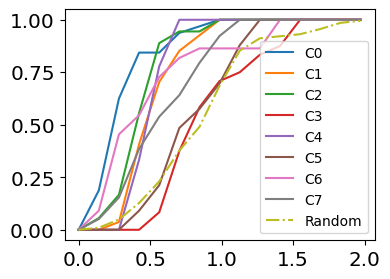

In [179]:
import random
fig,ax = plt.subplots(figsize=(4,3))
somadists=[]
maxdist=0
def dist2center(columns):
    maxdist=0
    allsomas=None
    somadist=[]
    neuronsomas = []
    for j in range(len(columns)):
        neuron={}
        neuron['sampleid']=columns[j][0:6]
        neuron['name']=columns[j][6:]
        property = iondata.getNeuronPropertyByID(neuron['sampleid'], neuron['name'])
        neuronsomas.append( property['somapoint'] )
    somas = np.array(neuronsomas)
    if allsomas is None:
        allsomas = somas
    else:
        allsomas= np.vstack([allsomas,somas])
    sum=0
    averagesoma = somas.mean(0)
    print(averagesoma)
    for neuronsoma1 in somas:
        dist = np.sqrt(np.sum(np.square(neuronsoma1 - averagesoma)))/1000
        if maxdist<dist :
            maxdist=dist

        somadist.append(dist)
    somadist.sort()
    return somadist,maxdist
for i in range(np.max(cluster)):
    columns = df.columns[cluster==(i+1)]
    somadist ,maxdist0= dist2center(columns)
    if maxdist<maxdist0:
        maxdist = maxdist0
    somadists.append(somadist)

somadist ,maxdist0= dist2center(df.columns)
somadists.append(somadist)
if maxdist<maxdist0:
    maxdist = maxdist0

x= np.linspace(0,maxdist,num = 15)

for j in range(len(somadists)):
    somadist = somadists[j]
    y=[]
    for i in x:
        count=(somadist<i)
        # print(count)
        y.append(np.sum(count)/len(somadist))
    print(y)
    p = np.poly1d(np.polyfit(x, y, 4))
    t = np.linspace(0, maxdist, 15)
    if j==8:
        plt.plot(x, y, '-.',label ='Random')
    else:
        plt.plot(x, y, '-',label ='C'+str(j))
    # plt.show()
    # break
plt.xticks(np.linspace(0,2,num = 5),fontsize='x-large')
plt.yticks(np.linspace(0,1,num = 5),fontsize='x-large')

plt.legend()

In [23]:
import Visual as nv

neuronvis = nv.neuronVis(renderModel=0)
neuronvis.render.setBackgroundColor((1.0,1.00,1.0,1.0))
# neuronvis.addRegion('TH')
# neuronvis.clear(root=True,neurons=True,regions=False)
clustertemp = cluster
for i in range(np.max(clustertemp)):
    columns = df.columns[clustertemp==(i+1)]
    neurons = []
    
    for j in range(len(columns)):
        neuron={}

        neuron['sampleid']=columns[j][0:6]
        neuron['name']=columns[j][6:]
        neurons.append(neuron)
        
        neuronvis.addNeuronByID(neuron['sampleid'], neuron['name'],color=[color[i][0]/255,color[i][1]/255,color[i][2]/255],mirrorToRight=True,dendriteHide=False,axonHide=False)
        # break
    print(i,len(neurons),color[i])
    neuronvis.render.setView('left')
    # neuronvis.render.setLookAt(eye=(-5000.,0.0,0),center=(0,0,0),up=(0,-1,0))
    # neuronvis.render.setPointSize(200)
    neuronvis.render.savepng('../resource/thsample/clusterLeft'+str(i)+'.png')
    neuronvis.clear()
    # break
neuronvis.render.closeWindow()
    

exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/080.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/068.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/069.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/073.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/074.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/077.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/078.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/079.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/086.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210727/031.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/211986/056.swc
exist  d:\project\python\neuron-

In [33]:
neuronvis = nv.neuronVis(renderModel=0)
neuronvis.render.setBackgroundColor((1.0,1.00,1.0,1.0))
neuronvis.addRegion('SSs',color=[0.5,0.5,0.5])
neurons=[{'sampleid':'210727','name':'031.swc','cluster':'1'},
{'sampleid':'210662','name':'066.swc','cluster':'2'},
{'sampleid':'210661','name':'166.swc','cluster':'3'},
{'sampleid':'210726','name':'061.swc','cluster':'6'},
{'sampleid':'210661','name':'042.swc','cluster':'8'}]

for neuron in neurons:

    neuronvis.addNeuronByID(neuron['sampleid'], neuron['name'],color=[1,0,0],mirrorToRight=True,dendriteHide=False,axonHide=False)

    neuronvis.render.setView('posterior')
    neuronvis.render.savepng('../resource/thsample/clusterSSsPosterior'+neuron['cluster']+'.png')
    neuronvis.clear(regions=False)
# break
neuronvis.render.closeWindow()
# neuronvis.render.run()

specified material (mtl1)  not loaded!


exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210727/031.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210662/066.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210661/166.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/061.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210661/042.swc


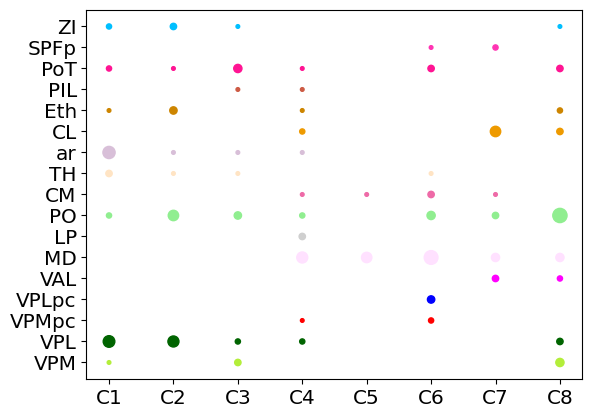

In [180]:
clustertemp = cluster
neurons = []
for i in range(np.max(clustertemp)):
	columns = df.columns[clustertemp==(i+1)]
	
	for j in range(len(columns)):
		neuron={}
		neuron['sampleid']=columns[j][0:6]
		neuron['name']=columns[j][6:]
		prop = iondata.getNeuronPropertyByID(neuron['sampleid'],neuron['name'])
		neuron['soma']=prop['somaregion']
		neuron['cluster']=i+1
		neuron['num']=1
		neurons.append(neuron)
regionclusterdf = pd.DataFrame(neurons)
# regionclusterdf.loc[regionclusterdf['cluster']==1]
testa= regionclusterdf.groupby(['soma','cluster'])['num'].sum()
testb=[]
for region in source_regions_sort_index:
	test={}
	test['region']=region
	for i in range(np.max(clustertemp)):
		test[i+1]=0
	if region in testa:
		for i in testa[region].keys():
			if testa[region][i]>=0:
				test[i]=testa[region][i]*7
			# print(region,i)
		testb.append(test)
	pass
dataframeb = pd.DataFrame(testb)
regions = dataframeb['region'].to_list()

regionnum = len(dataframeb[1].to_list())
for k in range(np.max(clustertemp)):
	# print(k)

    regioncolors = []
    for j in range(regionnum):
        regioncolor = source_regions_color[source_regions_sort_index.index(regions[j])]
        regioncolor = rgbToHex(regioncolor[0],regioncolor[1],regioncolor[2])
        regioncolors.append(regioncolor)
    
    plt.scatter(np.ones(regionnum)*(k+1),range(regionnum),  s=dataframeb[k+1].to_list(),c=regioncolors)
plt.yticks(range(regionnum),dataframeb['region'].to_list(),fontsize='x-large')
label=[]
for i in range(1,np.max(clustertemp)+1):
	label.append('C'+str(i))
plt.xticks(range(1,np.max(clustertemp)+1),label,fontsize='x-large')
plt.show()


In [181]:
regionclusterdf

,sampleid,name,soma,cluster,num
0,210726,080.swc,VPM,1,1
1,210726,068.swc,VPL,1,1
2,210726,069.swc,VPL,1,1
3,210726,073.swc,VPL,1,1
4,210726,074.swc,VPL,1,1
...,...,...,...,...,...
199,210661,056.swc,Eth,8,1
200,210661,059.swc,PoT,8,1
201,210662,117.swc,PoT,8,1
202,210726,110.swc,PoT,8,1


In [182]:
t11 =regionclusterdf
# print(testb)
neuronRegionCluster=None
for regiondata in testb:
    for i in range(1,9):
        if regiondata[i]>0:
            regionNeuronstemp = t11[(t11['soma']==regiondata['region']) & (t11['cluster']==i) ]
            if neuronRegionCluster is None:
                neuronRegionCluster = regionNeuronstemp
            else:
                # print(regionNeuronstemp)
                neuronRegionCluster=pd.concat([neuronRegionCluster,regionNeuronstemp])
neuronRegionCluster


,sampleid,name,soma,cluster,num
0,210726,080.swc,VPM,1,1
59,210726,131.swc,VPM,3,1
60,210726,132.swc,VPM,3,1
61,211986,068.swc,VPM,3,1
165,210661,146.swc,VPM,8,1
...,...,...,...,...,...
56,210726,085.swc,ZI,2,1
57,210727,006.swc,ZI,2,1
58,210727,021.swc,ZI,2,1
76,210727,028.swc,ZI,3,1


In [183]:
gb = neuronRegionCluster.groupby(['cluster'])
gb_dic = list(gb)
# print(gb_dic)
propmat0=[]
columns=[]
for i in range(len(gb_dic)):
    # print(gb_dic[i][0])
    columns.append('C'+str(gb_dic[i][0]))
    propmat=[]
    for row in gb_dic[i][1].itertuples():
        if 1:
            property = iondata.getNeuronPropertyByID(row[1],row[2])
            brproperty=BR.RegionProperty(copy.deepcopy(br))
            brpropertyLeft=BR.RegionProperty(copy.deepcopy(br))
            brpropertyRight=BR.RegionProperty(copy.deepcopy(br))
            brproperty.setProperty(property['projectregion'])
            brpropertyLeft.setProperty(property['projectleftregion'])
            brpropertyRight.setProperty(property['projectrightregion'])
            prop=[]
            for targetRegion in target_regions:
                regionsum = brproperty.getSumProperty(targetRegion)
                regionleft = brpropertyLeft.getSumProperty(targetRegion)
                regionright = brpropertyRight.getSumProperty(targetRegion)
                ipsi=0
                contra=0
                if property['somapoint'][2]<5700:
                    ipsi=regionleft
                    contra=regionright
                else:
                    ipsi=regionright
                    contra=regionleft
                prop.append(ipsi)
            if np.array(prop).sum()>10:
                propmat.append(prop)
    propmat0.append(np.array(propmat).mean(0))

    pass

In [29]:
gb = neuronRegionCluster.groupby(['soma','cluster'])
gb_dic = list(gb)
propmat0=[]
columns=[]
for i in range(len(gb_dic)):
    print(gb_dic[i][0])
    columns.append(gb_dic[i][0][0]+str(gb_dic[i][0][1]))
    propmat=[]
    for row in gb_dic[i][1].itertuples():
        # print(row[1],row[2])
        if 1:
            property = iondata.getNeuronPropertyByID(row[1],row[2])
            brproperty=BR.RegionProperty(copy.deepcopy(br))
            brpropertyLeft=BR.RegionProperty(copy.deepcopy(br))
            brpropertyRight=BR.RegionProperty(copy.deepcopy(br))
            brproperty.setProperty(property['projectregion'])
            brpropertyLeft.setProperty(property['projectleftregion'])
            brpropertyRight.setProperty(property['projectrightregion'])
            prop=[]
            for targetRegion in target_regions:
                regionsum = brproperty.getSumProperty(targetRegion)
                regionleft = brpropertyLeft.getSumProperty(targetRegion)
                regionright = brpropertyRight.getSumProperty(targetRegion)
                ipsi=0
                contra=0
                if property['somapoint'][2]<5700:
                    ipsi=regionleft
                    contra=regionright
                else:
                    ipsi=regionright
                    contra=regionleft
                prop.append(ipsi)
            if np.array(prop).sum()>10:
                propmat.append(prop)
    propmat0.append(np.array(propmat).sum(0))

    pass

('CL', 6)
('CL', 7)
('CL', 8)
('CL', 9)
('CM', 4)
('CM', 5)
('CM', 7)
('CM', 8)
('Eth', 1)
('Eth', 2)
('Eth', 6)
('Eth', 7)
('LP', 7)
('MD', 4)
('MD', 5)
('MD', 6)
('MD', 7)
('MD', 8)
('MD', 9)
('PIL', 3)
('PIL', 7)
('PO', 1)
('PO', 2)
('PO', 3)
('PO', 5)
('PO', 6)
('PO', 7)
('PO', 8)
('PO', 9)
('PoT', 1)
('PoT', 2)
('PoT', 3)
('PoT', 5)
('PoT', 6)
('PoT', 7)
('SPFp', 5)
('SPFp', 8)
('TH', 1)
('TH', 2)
('TH', 3)
('TH', 5)
('VAL', 8)
('VAL', 9)
('VPL', 1)
('VPL', 2)
('VPL', 3)
('VPL', 7)
('VPL', 9)
('VPLpc', 5)
('VPM', 2)
('VPM', 3)
('VPM', 6)
('VPM', 7)
('VPM', 9)
('VPMpc', 5)
('VPMpc', 7)
('ZI', 1)
('ZI', 2)
('ZI', 3)
('ZI', 9)
('ar', 1)
('ar', 2)
('ar', 3)
('ar', 7)


In [187]:
propmat0

[array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.11343175e+03,
        1.36420426e+04, 0.00000000e+00, 6.35966818e+02, 4.02109467e+03,
        4.66207747e+03, 1.44588503e+04, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 2.75103667e+01, 2.93439932e+03,
        1.61365251e+02, 8.13720173e+02, 4.42362881e+03, 0.00000000e+00,
        0.00000000e+00, 1.18180837e+01, 0.00000000e+00, 0.00000000e+00,
        2.32002326e+03, 3.00458308e+01, 0.00000000e+00, 7.19322753e+00,
        3.86532033e+02, 1.82637916e+02, 0.00000000e+00]),
 array([0.00000000e+00, 9.04572269e+02, 2.39868810e+03, 2.35491874e+04,
        1.07716677e+04, 0.00000000e+00, 9.65350792e+02, 2.51643712e+03,
        3.77790713e+03, 7.97384352e+03, 1.09698290e+02, 7.72403202e+01,
      

([<matplotlib.axis.XTick at 0x2b589236c40>,
 [Text(0.5, 0, 'C1'),
  Text(1.5, 0, 'C2'),
  Text(2.5, 0, 'C3'),
  Text(3.5, 0, 'C4'),
  Text(4.5, 0, 'C5'),
  Text(5.5, 0, 'C6'),
  Text(6.5, 0, 'C7'),
  Text(7.5, 0, 'C8')])

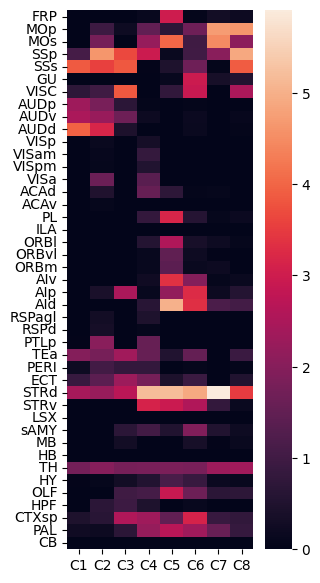

In [184]:
propmat0
mat = np.array(propmat0)
mat = np.log2(mat.T/1000.0+1)
th=5
# mat[mat<th]=0
# mat[mat>th]=1
fig,ax = plt.subplots(figsize=(3,7))

sns.heatmap(mat)
plt.yticks([index+0.5 for index in range(len(target_regions))],target_regions,rotation = 0)
plt.xticks([index+0.5 for index in range(len(columns))],columns,rotation = 0)


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import time

gb = neuronRegionCluster.groupby(['cluster'])
gb_dic = list(gb)
# print(gb_dic)
propmat2=[]
columns=[]
for i in range(len(gb_dic)):
    # print(gb_dic[i][0])
    columns.append('C'+str(gb_dic[i][0]))
    propmat=[]
    for row in gb_dic[i][1].itertuples():
        if 1:
            property = iondata.getNeuronPropertyByID(row[1],row[2])
            brproperty=BR.RegionProperty(copy.deepcopy(br))
            brpropertyLeft=BR.RegionProperty(copy.deepcopy(br))
            brpropertyRight=BR.RegionProperty(copy.deepcopy(br))
            brproperty.setProperty(property['projectregion'])
            brpropertyLeft.setProperty(property['projectleftregion'])
            brpropertyRight.setProperty(property['projectrightregion'])
            prop=[]
            for targetRegion in target_regions:
                regionsum = brproperty.getSumProperty(targetRegion)
                regionleft = brpropertyLeft.getSumProperty(targetRegion)
                regionright = brpropertyRight.getSumProperty(targetRegion)
                ipsi=0
                contra=0
                if property['somapoint'][2]<5700:
                    ipsi=regionleft
                    contra=regionright
                else:
                    ipsi=regionright
                    contra=regionleft
                prop.append(ipsi)
            if np.array(prop).sum()>10:
                propmat.append(prop)
    propmat2.append(propmat)

    pass
# print(propmat2)

# positions=[1,2,4,7]
# data=[
#     np.random.normal(1,5,10).tolist(),
#     np.random.normal(20,5,100).tolist(),
#     np.random.normal(30,5,100).tolist(),
#     np.random.normal(40,5,100).tolist(),
# ]

# print(len(data))

# fig,ax=plt.subplots()

# ax.violinplot(data,positions,showmeans=True,showmedians=True)


['FRP', 'MOp', 'MOs', 'SSp', 'SSs', 'GU', 'VISC', 'AUDp', 'AUDv', 'AUDd', 'VISp', 'VISam', 'VISpm', 'VISa', 'ACAd', 'ACAv', 'PL', 'ILA', 'ORBl', 'ORBvl', 'ORBm', 'AIv', 'AIp', 'AId', 'RSPagl', 'RSPd', 'PTLp', 'TEa', 'PERI', 'ECT', 'STRd', 'STRv', 'LSX', 'sAMY', 'MB', 'HB', 'TH', 'HY', 'OLF', 'HPF', 'CTXsp', 'PAL', 'CB']
[0.0625, 0.07692307692307693, 0.05555555555555555, 0.5416666666666666, 0.5555555555555556, 0.5151515151515151, 0.8181818181818182, 0.1282051282051282]
[0.85 1.85 2.85 3.85 4.85 5.85 6.85 7.85]
[0.0, 0.0, 0.0, 0.20833333333333334, 0.0, 0.15151515151515152, 0.0, 0.0]
[1.15 2.15 3.15 4.15 5.15 6.15 7.15 8.15]


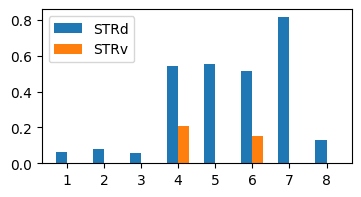

In [349]:
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        plt.text(rect.get_x()+rect.get_width()/2.-0.2, 1.03*height, '%s' % float(height))

# print((propmat2[0]))
print(target_regions)
positions=range(1,9)
fig,ax=plt.subplots(figsize=(4,2))
# plt.subplots_adjust(left=None,bottom=None,right=None,top=None,wspace=0,hspace=0)
i=0
j=-1
bar_width=0.3
for region in target_regions:
    data=[]

    for c in range(len(propmat2)):
        # print(len(propmat2[c]))
        proparray2 = np.array(propmat2[c])# print(propmat2[c])
        proparray2 = proparray2.T
        p = proparray2[i]>15000
        p = p.sum()/len(p)
        data.append(p)
    
    
    
    if region=='STRd' or region=='STRv' :
        print(data)
        print(np.array(range(1,9))+bar_width*i-9.15)
        plt.bar(np.array(range(1,9))+bar_width*i-9.15,data,width = bar_width,label=region)
    i+=1
plt.xticks([1,2,3,4,5,6,7,8])
plt.legend()



['FRP', 'MOp', 'MOs', 'SSp', 'SSs', 'GU', 'VISC', 'AUDp', 'AUDv', 'AUDd', 'VISp', 'VISam', 'VISpm', 'VISa', 'ACAd', 'ACAv', 'PL', 'ILA', 'ORBl', 'ORBvl', 'ORBm', 'AIv', 'AIp', 'AId', 'RSPagl', 'RSPd', 'PTLp', 'TEa', 'PERI', 'ECT', 'STRd', 'STRv', 'LSX', 'sAMY', 'MB', 'HB', 'TH', 'HY', 'OLF', 'HPF', 'CTXsp', 'PAL', 'CB']


[Text(1, 0, 'C1'),
 Text(2, 0, 'C2'),
 Text(3, 0, 'C3'),
 Text(4, 0, 'C4'),
 Text(5, 0, 'C5'),
 Text(6, 0, 'C6'),
 Text(7, 0, 'C7'),
 Text(8, 0, 'C8')]

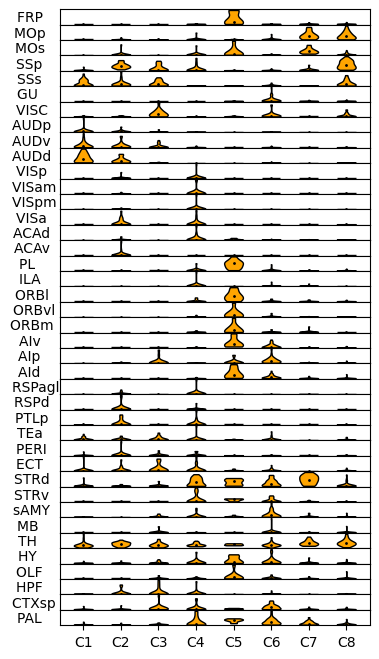

In [317]:
# import seaborn as sns
# print((propmat2[0]))
print(target_regions)
positions=range(1,9)
fig,ax=plt.subplots(len(target_regions)-3,1,figsize=(4,8))
plt.subplots_adjust(left=None,bottom=None,right=None,top=None,wspace=0,hspace=0)
i=0
j=-1
for region in target_regions:
    data=[]

    for c in range(len(propmat2)):
        # print(len(propmat2[c]))
        proparray2 = np.array(propmat2[c])# print(propmat2[c])
        proparray2 = proparray2.T
        data.append(proparray2[i])
    i+=1
    
    
    if region=='LSX' or region=='HB' or region=='CB':

        continue
    j+=1

    ax[j].set_yticks([])
    ax[j].set_xticks([])
    ax[j].set_ylabel(region.ljust(12),rotation=0,y=0)
    # ax[i].axis('off')
    part= ax[j].violinplot(data,positions,showextrema = False,showmeans=False)
    # q1,me,q3 = np.percentile(np.array(data),[25,50,75],axis=1)
    me = [np.median(d) for d in data]
    ind = np.arange(1,9)
    # # print(data)
    ax[j].scatter(ind,me,marker="o",color="k",s=1,zorder=3)
    for pc in part["bodies"]:
        pc.set_facecolor("orange")
        pc.set_edgecolor("black")
        pc.set_alpha(1)
        pc.set_linestyle("-")

ax[j].set_xticks([1,2,3,4,5,6,7,8])
ax[j].set_xticklabels(['C1','C2','C3','C4','C5','C6','C7','C8'])
# ax[j].set_xticklabels(['C1','C2','C3','C4','C5','C6','C7','C8'])


[array([-1.66020696,  0.62007441,  2.37690524, -1.30570012,  2.81550355,
       -2.16324639, -0.68345819,  0.27985056,  5.68695056,  3.21774326,
        1.08652283, -2.9649015 ,  0.18547399,  1.81528518, -3.20571662,
       -0.46021495,  3.02357423, -0.05834895, -0.54141792, -3.81713579,
        3.55563586, -0.23167625,  0.63169192, -1.26661793, -1.80848038,
       -2.21114145,  1.62995427,  3.61265149, -0.1912036 , -1.15352161,
       -1.99615512,  0.93154884,  0.60763261,  2.74183724,  6.34127206,
       -1.97530573, -1.58043752,  3.09695518, -2.67730588,  0.85716842,
       -0.8294543 ,  0.45836663, -2.07819515, -3.64529584,  2.79811803,
        1.43408143,  1.17594315, -1.20875543, -1.22095403, -3.78939717,
       -4.53559059, -1.87059881, -4.4769064 , -0.4055706 , -0.01681173,
       -0.3045538 , -0.47721307, -0.21793413,  0.98036166,  1.51165483,
        4.70595549, -2.90264515, -2.82147685, -1.07244917, -0.07099027,
       -1.96814567, -0.22289547,  2.3880784 ,  1.60229048, -1.8

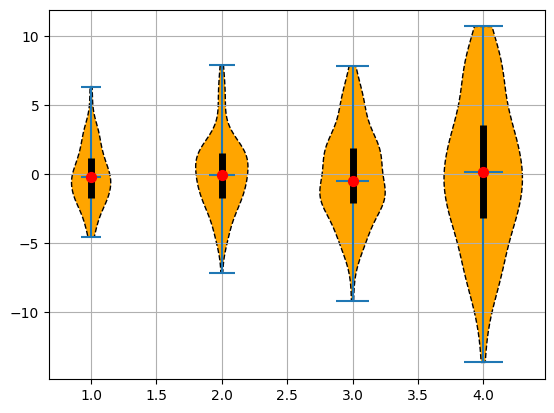

In [304]:
data = [np.random.normal(0,i,100) for i in range(2,6)]
plt.grid()
part = plt.violinplot(data,showmedians=True,widths=[0.3,0.4,0.5,0.6])
for pc in part["bodies"]:
    print(pc)
    pc.set_facecolor("orange")
    pc.set_edgecolor("black")
    pc.set_alpha(1)
    pc.set_linestyle("--")

q1,me,q3 = np.percentile(data,[25,50,75],axis=1)
ind = np.arange(1,len(me)+1)
print(data)
plt.scatter(ind,me,marker="o",color="r",s=50,zorder=3)
plt.vlines(ind,q1,q3,color="k",linestyles="-",lw=5)

In [ ]:
import FlatNeuron
from skimage import draw, io

grid,dv0,dv1,dv2,flatenPara = FlatNeuron.getStreamLine()
img0 = io.imread(r'../resource/flatmapedgebgd.png')
singleimg = img0
for i in range(max(cluster)):
    img0[:]=0
    neurons = df.columns[cluster==(i+1)]
    for neuron in neurons:
        singleimg[:]=0
        print(i,neuron)
        neurontree = iondata.getNeuronTreeByID(neuron[0:6], neuron[6:])
        FlatNeuron.flatneuron(neurontree,grid,dv0,dv1,dv2,flatenPara,sum=True,img=singleimg)
        io.imsave("../resource/thsample/flatmap/"+neuron[0:-4]+'flatbgd.png',singleimg)
        img0+=singleimg
    io.imsave("../resource/thsample/flatmap/modulecluster"+str(i)+'flatbgd.png',img0)


In [304]:
img0 = io.imread(r'../resource/flatmapedgebgd.png')
for i in range(max(cluster)):
    img0[:]=0
    neurons = df.columns[cluster==(i+1)]
    print(i,(neurons))
    for neuron in neurons:
        singleimg = io.imread("../resource/thsample/flatmap/"+neuron[0:-4]+'flatbgd.png')
        img0+=singleimg
    io.imsave("../resource/thsample/flatmap/modulecluster2-"+str(i)+'flatbgd.png',img0)


0 Index(['210726080.swc', '210726068.swc', '210726069.swc', '210726073.swc',
       '210726074.swc', '210726077.swc', '210726078.swc', '210726079.swc',
       '210726086.swc', '210727031.swc', '211986056.swc', '210661046.swc',
       '210661171.swc', '210727001.swc', '210727055.swc', '211986036.swc',
       '210726070.swc', '210726071.swc', '210726072.swc', '210727002.swc',
       '210727003.swc', '210727005.swc', '210727019.swc', '210727030.swc',
       '210727032.swc', '210727033.swc', '210727056.swc', '210661177.swc',
       '210661167.swc', '210661176.swc', '210727004.swc', '210727020.swc'],
      dtype='object')
1 Index(['210726065.swc', '210726066.swc', '210726067.swc', '210726075.swc',
       '210726076.swc', '210726082.swc', '210726084.swc', '210726087.swc',
       '210726088.swc', '210661045.swc', '210661168.swc', '210661169.swc',
       '210661170.swc', '210661172.swc', '210661179.swc', '210662066.swc',
       '210662067.swc', '211986037.swc', '210727018.swc', '210661052.swc'

In [303]:
from skimage import filters
lut = pd.read_csv('../resource/LUT.csv')
lut = lut.to_numpy()
lut=lut[:,1:4]
print(lut[0])
maxvalue=0
imgbgd = io.imread(r'../resource/flatmapedge.png')
for i in range(max(cluster)):
    clusterimg = io.imread("../resource/thsample/flatmap/modulecluster2-"+str(i)+'flatbgd.png')
    print(i,np.max(clusterimg))
    if np.max(clusterimg)==0:
        continue
    if maxvalue<np.max(clusterimg):
        maxvalue=np.max(clusterimg)
for i in range(max(cluster)):
    if os.path.isfile("../resource/thsample/flatmap/modulecluster2-"+str(i)+'flatbgd.png'):
        clusterimg = io.imread("../resource/thsample/flatmap/modulecluster2-"+str(i)+'flatbgd.png')
        img = clusterimg*255/maxvalue
        img1 = filters.gaussian(img,sigma=4)
        img1 = img1[:,:,0]
        img2 = img1.reshape([img1.shape[0]*img1.shape[1]])
        # print(region)
        img2 = img2*40
        img2=img2.astype(np.int8)
        img3 = lut[img2]
        img4 = img3.reshape([img1.shape[0],img1.shape[1],3])
        img4[imgbgd[:,:,0]==0]=[0,0,0]
        io.imsave("../resource/thsample/flatmap/module2"+str(i)+'flatblur.png',img4)

[255 255 255]
0 50
1 37
2 42
3 24
4 29
5 32
6 28
7 55


d:\Program Files\anaconda3\envs\neuronVis\lib\site-packages\skimage\_shared\utils.py:348: RuntimeWarning: Images with dimensions (M, N, 3) are interpreted as 2D+RGB by default. Use `multichannel=False` to interpret as 3D image with last dimension of length 3.
  return func(*args, **kwargs)
D:\project\python\AppData\Local\Temp\ipykernel_2560\546297114.py:28: UserWarning: ../resource/thsample/flatmap/module20flatblur.png is a low contrast image
  io.imsave("../resource/thsample/flatmap/module2"+str(i)+'flatblur.png',img4)
Lossy conversion from int64 to uint8. Range [0, 255]. Convert image to uint8 prior to saving to suppress this warning.
D:\project\python\AppData\Local\Temp\ipykernel_2560\546297114.py:28: UserWarning: ../resource/thsample/flatmap/module21flatblur.png is a low contrast image
  io.imsave("../resource/thsample/flatmap/module2"+str(i)+'flatblur.png',img4)
Lossy conversion from int64 to uint8. Range [0, 255]. Convert image to uint8 prior to saving to suppress this warning.
D

179 9 [4 1 6 9 8 6 6 8 5 7 7 2 1 3 6 6 5 8 4 6 1 4 9 6 7 6 7 6 9 2 3 2 6 1 9 6 6
 2 5 9 8 4 6 1 6 7 9 6 8 4 5 7 3 7 3 6 3 6 6 1 9 8 6 6 8 8 2 1 1 6 2 1 1 9
 6 7 2 3 7 4 8 9 6 7 1 2 6 1 2 2 6 9 8 9 6 6 3 5 2 4 6 7 3 9 5 4 3 5 7 5 7
 6 3 6 1 8 8 6 3 8 6 8 9 6 5 6 6 6 9 1 1 9 1 5 4 8 6 6 1 6 2 6 8 6 1 1 3 3
 4 6 5 6 3 8 6 9 1 4 1 9 2 4 6 8 4 6 6 8 4 2 6 1 7 7 9 6 6 8 7]


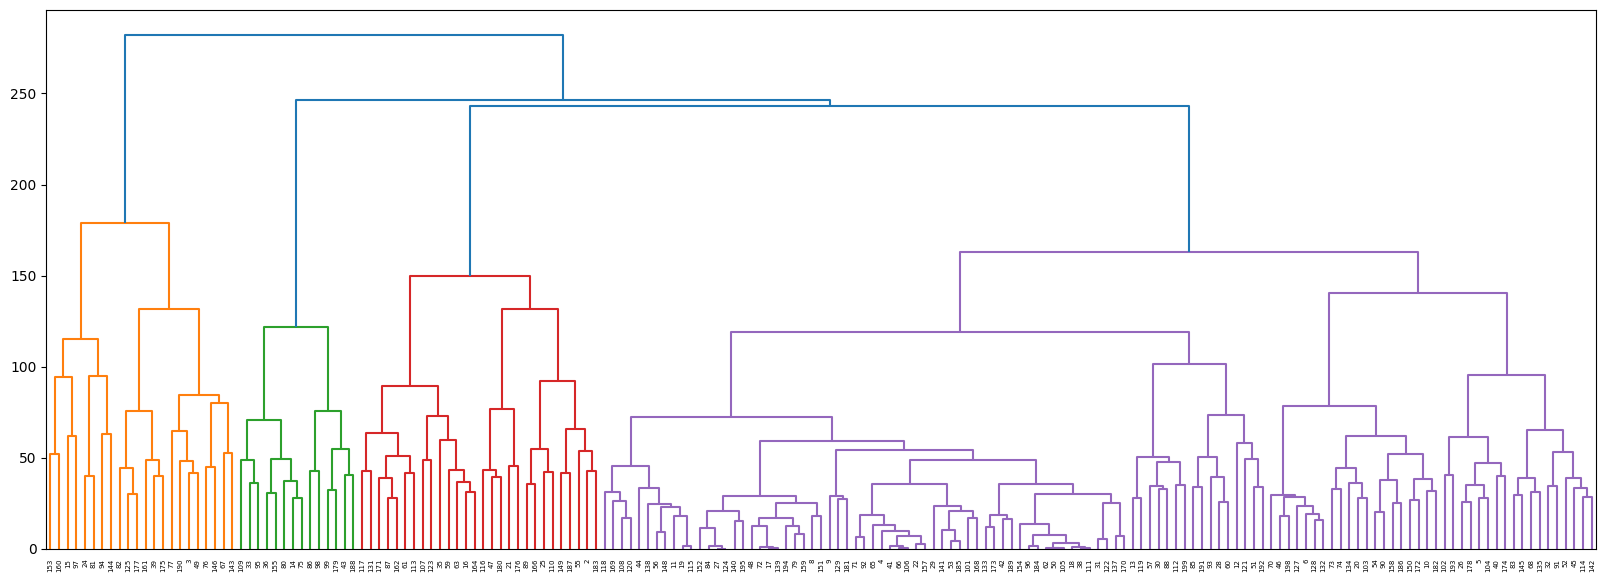

In [26]:
fig,ax = plt.subplots(figsize=(20,7))
def fclusterDF2(dataframe):
		matData =  dataframe.values[:,:].transpose()
		distance = spatial.distance.pdist(matData.astype(float))
		linkresult = linkage(distance,method='ward',metric='euclidean')
		
		cluster=fcluster(linkresult,t=3.15,criterion='inconsistent',depth=25,R=None,monocrit=None)#这个需要先计算linkage，再出结果
		dendrogram(linkresult,labels=dataframe.columns[:])
		return cluster
cluster = fclusterDF2(df.T)
print(len(cluster),np.max(cluster),cluster)



#010000


22 Rectangle(xy=(0.1, 47.4), width=0.1, height=6.6, angle=0) #F00
14 Rectangle(xy=(0.1, 43.2), width=0.1, height=4.2, angle=0) #0F0
14 Rectangle(xy=(0.1, 39), width=0.1, height=4.2, angle=0) #00F
14 Rectangle(xy=(0.1, 34.8), width=0.1, height=4.2, angle=0) #808080
11 Rectangle(xy=(0.1, 31.5), width=0.1, height=3.3, angle=0) #F0F
50 Rectangle(xy=(0.1, 16.5), width=0.1, height=15, angle=0) #3CFFAF
16 Rectangle(xy=(0.1, 11.7), width=0.1, height=4.8, angle=0) #FF9B00
20 Rectangle(xy=(0.1, 5.7), width=0.1, height=6, angle=0) #699B37
18 Rectangle(xy=(0.1, 0.3), width=0.1, height=5.4, angle=0) #9B9BCD
[49.800000000000004, 51.0, 52.2, 44.4, 45.599999999999994, 40.199999999999996, 41.39999999999999, 36.0, 37.199999999999996, 32.25000000000001, 33.45, 34.650000000000006, 23.1, 24.3, 25.5, 13.200000000000001, 14.400000000000002, 15.600000000000001, 7.8000000000000025, 9.000000000000004, 1.2000000000000002, 2.4, 3.6, 4.8] ['SSs', 'SSp', 'AUD', 'AI', 'GU', 'SSs', 'SSp', 'MOp', 'MOs', 'TEa', 'AUD', 

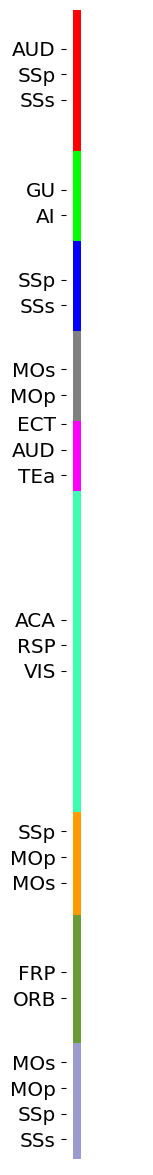

In [31]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(1,15))
ax = fig.add_subplot(111)
ax.set_ylim(0,54)
ax.set_xlim(0,1)
# ax = plt.axes()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
start=0
regionlabels=[['SSs','SSp','AUD'],['AI','GU'],['SSs','SSp'],
['MOp','MOs'],['TEa','AUD','ECT'],['VIS','RSP','ACA'],
['MOs','MOp','SSp'],['ORB','FRP'],['SSs','SSp','MOp','MOs']]
labelstemp =[]
yindex =[]
for i in range(np.max(cluster)):
    columns = df.T.columns[cluster==(i+1)]
    # print(columns)
    regionlabel = regionlabels[i]
    clustercenter = 54-0.3*len(columns)/2-start
    j=-3*int(len(regionlabel)/2)
    for label in regionlabel:
        # print(label)
        yindex.append(clustercenter+j*0.3)
        j+=4
        labelstemp.append(label)
    rect = plt.Rectangle((0.1,54-0.3*len(columns)-start),0.1,0.3*len(columns),facecolor=rgbToHex(color[i][0],color[i][1],color[i][2]))
    # rect.set_facecolor(rgbToHex(color[i][0],color[i][1],color[i][2]))
    print(len(columns),rect,rgbToHex(color[i][0],color[i][1],color[i][2]))
    start=start+0.3*len(columns)
    ax.add_patch(rect)
    pass
# rect = plt.Rectangle((0.1,4.1),0.5,0.3)
# print(rect)
# ax.add_patch(rect)
# plt.xticks([])
print(yindex,labelstemp)
plt.yticks(yindex,labelstemp,rotation = 0,fontsize='x-large')
plt.xticks([])
# plt.axis('off')

plt.show()


In [99]:
from skimage import draw, io

isomoduleflatmap = io.imread("../resource/isomoduleflatmap.png")
flatmapedge = io.imread("../resource/flatmapedge.png")
isomoduleflatmapedge = io.imread("../resource/isomoduleflatmap-1.png")
isomodule = np.zeros([isomoduleflatmap.shape[0],isomoduleflatmap.shape[1],3])+255
for i in range(np.max(cluster)):
    dfT=df.T
    columns = dfT.columns[cluster==(i+1)]
    for j in range(len(columns)):
        isomodule[isomoduleflatmap==columns[j]]=color[i]
    # print(len(columns),columns)
isomodule[isomoduleflatmapedge[:,:]==255]=[0,0,0]

isomodule[flatmapedge[:,:,1]<120]=[0,0,0]
io.imsave("../resource/isomodule2.png",isomodule)

Lossy conversion from float64 to uint8. Range [0.0, 255.0]. Convert image to uint8 prior to saving to suppress this warning.


In [96]:
flatmapedge.shape

(1500, 1500, 4)

In [ ]:
import Flatmap
import BoundLaplace
import nrrd
import numpy as np

layer = [120, 400, 570, 850, 1200] # in micron, SS results employing ../neuronVis/LayerThickness.py
layerName = ['L1','L2/3','L4','L5','L6']
iondata = IONData.IONData()

flatenPara=Flatmap.createSurfaceGraph()

res,gridpath = iondata.getFileFromServer("boundlaplace20.nrrd")
grid,header = nrrd.read(gridpath)

resRelaxation,RelaxationPath=iondata.getFileFromServer('boundlaplaceout20.nrrd')
relaxation,relaxationheader = nrrd.read(RelaxationPath)

resdv0,dv0Path=iondata.getFileFromServer('dv0.nrrd')
dv0,dv0header = nrrd.read(dv0Path)
resdv1,dv1Path=iondata.getFileFromServer('dv1.nrrd')
dv1,dv1header = nrrd.read(dv1Path)
resdv2,dv2Path=iondata.getFileFromServer('dv2.nrrd')
dv2,dv2header = nrrd.read(dv2Path)

dv0=dv0.astype(np.float32)/1000-1
dv1=dv1.astype(np.float32)/1000-1
dv2=dv2.astype(np.float32)/1000-1

In [ ]:
from fileinput import filename
import Scene

source_regions_VPMVPL = ['VPM','VPL','VPMpc','VPLpc']

list=[]
for region in source_regions_VPMVPL:
    list+=(regionNeurons[region])
Scene.createScene(list,filename='../resource/TH_VPMVPL.nv')

source_regions_other = ['LGd','MG','VAL','AM','SMT','MD','LP','PO','LD','VM','RE','CM','TH','ar','CL','Eth','PIL','PoT','SPFp','ZI']

list=[]
for region in source_regions_other:
    list+=(regionNeurons[region])
Scene.createScene(list,filename='../resource/TH_OTHER.nv')

In [ ]:

import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
%matplotlib inline
import FlatNeuron,Flatmap

grid,dv0,dv1,dv2,flatenPara = FlatNeuron.getStreamLine()



In [ ]:
neuronT = iondata.getNeuronTreeByID(regionNeurons['VPM'][1]['sampleid'], regionNeurons['VPM'][1]['name'])

FlatNeuron.flatneuron(neuronT,grid,dv0,dv1,dv2,flatenPara)

In [ ]:
regionNeurons['VPM']

In [ ]:
neuronT = iondata.getNeuronTreeByID(regionNeurons['VPM'][2]['sampleid'], regionNeurons['VPM'][2]['name'])

FlatNeuron.flatneuron(neuronT,grid,dv0,dv1,dv2,flatenPara)

In [ ]:
neuronT = iondata.getNeuronTreeByID('210098','004.swc')
FlatNeuron.flatneuron(neuronT,grid,dv0,dv1,dv2,flatenPara)
FlatNeuron.plt.savefig('../resource/thsample/flatmap/test.png', format='png', dpi=300)

In [11]:
import nrrd
moduleiso,header = nrrd.read("../resource/moduleiso.nrrd")
moduleiso.shape

(660, 400, 570)

In [15]:
moduleiso[221,121,176]

55